# Prática 1 — Pipeline de Pré-processamento com Filtros Lineares

**Disciplina:** Visão Computacional · CESAR School  
**Professor:** Eronides F. da Silva Neto  
**Integrante:** Phelipe Calado de Souza Costa  
**Instituição:** CESAR School Recife  
**Data:** 09/09/2026

---

## Sumário executivo

Este trabalho constrói um pipeline de pré-processamento restrito a filtros lineares para preparar 100 imagens de placas veiculares para reconhecimento automático por OCR, e propõe uma métrica de dois eixos para avaliá-lo.

A análise exploratória foi determinante para decisão das poss;iveis arquiteturas. O conjunto é dominado por **subexposição**, onde 37 das 100 imagens têm brilho médio abaixo de 30 e essa degradação é majoritariamente **reversível**: a perda irrecuperável por saturação atinge no máximo 17% da área na pior imagem e menos de 3% na maioria. O sinal cromático da placa **colapsa nas duas pontas** da distribuição de exposição (21,6 contra 64,9 de separação entre canais), o que desaconselha estratégias baseadas em cor. E as medidas usuais de nitidez são **contaminadas pela exposição**: um ganho de 5× multiplica a variância do Laplaciano por 25 sem que uma borda mude.

Duas arquiteturas foram implementadas e comparadas: uma de **cadeia sequencial** com unsharp mask e uma de **decomposição multiescala** com recombinação linear ponderada. A decomposição venceu pelo critério de estabilidade entre regimes de captura, confirmada por dois testes independentes.

**Resultado:** 

Nenhuma das 100 imagens é degradada em qualquer dos eixos. O contraste traço-fundo sobe de 0,174 para 0,432 e a dispersão entre regimes de exposição cai de 0,099 para 0,055. Assim, o desempenho deixa de depender de a foto ser diurna ou noturna.

Resposta à pergunta central: **um pipeline serve a todas?** Vendo esta configuração com uma única *topologia* que serve às 100 imagens sim. Mas vendo como um único conjunto de parâmetros, não. O uso de parâmetros fixos degradam 14 imagens, já se forem estimados por imagem, nenhuma. A generalização portanto, tem de vir da estrutura do pipeline, não da constância dos seus números. 

Sobre a restrição de linearidade, o seu custo foi dimensionado empiricamente em um rápido ensaio. Três dos quatro filtros não-lineares testados perdem para a solução linear; apenas o CLAHE representa ganho real (12,7% em contraste), por realçar contraste localmente onde a normalização afim atua de forma global. A restrição portanto, pesou apenas onde o problema é de variação dentro da imagem.

## Ambiente e reprodutibilidade

Projeto desenvolvido localmente em **VS Code**, com estrutura de diretórios fixa e caminhos relativos, de
modo que a execução não dependa da máquina nem da ordem manual das células.

```
pratica1_vc/
├── data/
│   ├── raw/                 # 100 imagens .jpg de entrada — IMUTÁVEL
├── ├── interim/             # intermediário, resultado de transformação parcial ou produção da EDA
│   └── processed/           # saídas geradas — descartável e regenerável
├── notebooks/
│   └── vc_pratica1_Phelipe_C_S_Costa.ipynb
├── requirements.txt
└── .gitignore
```


Para reproduzir: criar o ambiente virtual, instalar `requirements.txt`, colocar as imagens em
`data/raw/pratica1/` e executar o notebook de cima para baixo (*Run All*).

## Configurações iniciais

O bloco abaixo importa as bibliotecas e concentra todas as parametrizações em um único dicionário (boas práticas - separação entre configuração e execução).

Sobre os valores escolhidos:

Largura e altura (plate_w/plate_h): As imagens são de placas chinesas, que possuem 440 x 140 mm, que é uma razão de 3,14:1, de forma que o menor valor mais próximo desta proporção fica em 220 x 70px.
Percentis de normalização (pct_lo/pct_hi): 1 e 99 para normalizar contraste.
Tamanho fixo esperado (expected_size): As imagens são originadas do CCPD (Chinese City Parking Dataset) que têm tamanho fixo de 720 x 1160. Fixar esta relação funciona como protenção contra imagens fora deste padrão.

In [26]:
# =============================================================================
# CONFIGURAÇÃO GLOBAL
# Toda a parametrização do projeto vive neste bloco. Nenhuma célula adiante
# define constante própria — é o que permite reproduzir o projeto inteiro em
# outra configuração alterando um valor aqui e reexecutando.
# =============================================================================

from pathlib import Path
import sys, warnings

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline

SEED = 42
np.random.seed(SEED)

CONFIG = {
    # --- caminhos (relativos à pasta notebooks/) -----------------------------
    "raw_dir":       Path("../data/raw"),        # entrada, imutável
    "interim_dir":   Path("../data/interim"),    # tabelas analíticas
    "out_dir":       Path("../data/processed"),  # entregáveis

    # --- geometria de saída --------------------------------------------------
    "plate_w":       220,                        # placa: 440 x 140 mm
    "plate_h":       70,                         # razão 3,14:1

    # --- formato de saída ----------------------------------------------------
    "out_format":    "jpg",
    "jpeg_quality":  100,

    # --- normalização de intensidade ----------------------------------------
    "pct_lo":        1.0,                        # percentis usados para
    "pct_hi":        99.0,                       # estimar ganho e deslocamento

    # --- contrato de dados ---------------------------------------------------
    "expected_size": (720, 1160),                # (largura, altura) esperadas
}

# Cria apenas as pastas de escrita. 'raw_dir' fica de fora de propósito: é
# entrada, e se não existir queremos o erro, não uma pasta vazia criada em
# silêncio — que transformaria um problema de ambiente num sintoma distante.
for chave in ("interim_dir", "out_dir"):
    CONFIG[chave].mkdir(parents=True, exist_ok=True)

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("OpenCV :", cv2.__version__)
print("pandas :", pd.__version__)
print()
print("Entrada:", CONFIG["raw_dir"].resolve())
print("Interim:", CONFIG["interim_dir"].resolve())
print("Saída  :", CONFIG["out_dir"].resolve())
print()
print("Imagens encontradas:", len(list(CONFIG["raw_dir"].glob("*.jpg"))))

Python : 3.11.4
NumPy  : 2.4.6
OpenCV : 5.0.0
pandas : 3.0.5

Entrada: C:\Projetos_Tec\pre-processamento_placas_veiculares\pratica1_vc\data\raw
Interim: C:\Projetos_Tec\pre-processamento_placas_veiculares\pratica1_vc\data\interim
Saída  : C:\Projetos_Tec\pre-processamento_placas_veiculares\pratica1_vc\data\processed

Imagens encontradas: 100


## Parte 1 - Análise Inicial

### Problema e Objetivos

#### O problema

O dataset possui imagens de veículos e suas placas (informação de interesse) em condições reais e variadas. Algumas com vista frontal ou inclinada e até muito inclinada, fotos das placas vista dianteira ou traseira do carro, durante o dia ou durante a noite. Todas as placas tem fundo azul, letras brancas. Algumas placas com reflexos em parte do texto. Algumas imagens não estão nítidas (a olho humano).

A extração de informações das placas pode ser feita na forma clássica por um reconhecedor de caracteres (OCR - Optical Character Recognition, ou Reconhecimento Óptico de Caracteres), que para ser eficaz, depende de como é o contraste entre o traço (bordas) e o fundo, a definição destas bordas e a geometria (para possibilitar a comparação entre um provável caractere e outro). Se estas propriedades forem insuficientes na entrada do OCR, este não conseguirá extrair os caracteres. Por isto, a etapa de pré-processamento é fundamental para preparar o sinal de entrada.

### Objetivos

i. Construir um pipeline de pré-processamento feito exclusivamente por filtros lineares
ii. Propor uma métrica quantitativa para avaliar a qualidade do resultado
iii. Responder se um único pipeline serve às 100 imagens ou não, através dos resultados obtivos

#### Entregáveis

* Notebook vc_pratica1_<seu_nome>.ipynb, células já executadas.
* Arquivo .zip com as 100 imagens filtradas.
* Nome dos Integrantes da Equipe no arquivo notebook (.ipynb)
* Diagrama de Blocos da(s) sua(s) Pipeline(s)

#### Critérios de avaliação

i. Parte 1 — Análise Inicial (PESO 30%): Metodologia da análise do problema e possibilidade de como resolver.
ii. Parte 2 - Implementação (PESO 35%): Desenvolvimento da pipeline global, correção técnica e respeito à restrição de linearidade.
iii. Parte 3 — Análise dos Resultados(PESO 35%): Se as conclusões apresentadas se sustentam, baseado no desenvolvimento técnico. Avaliação da métrica proposta.

#### Fora de escopo

i. Fazer reconhecimento de caracteres
ii. Medir taxa de acerto do OCR.


Total de arquivos: 100
Dimensão (altura, largura, canais): (1160, 720, 3)


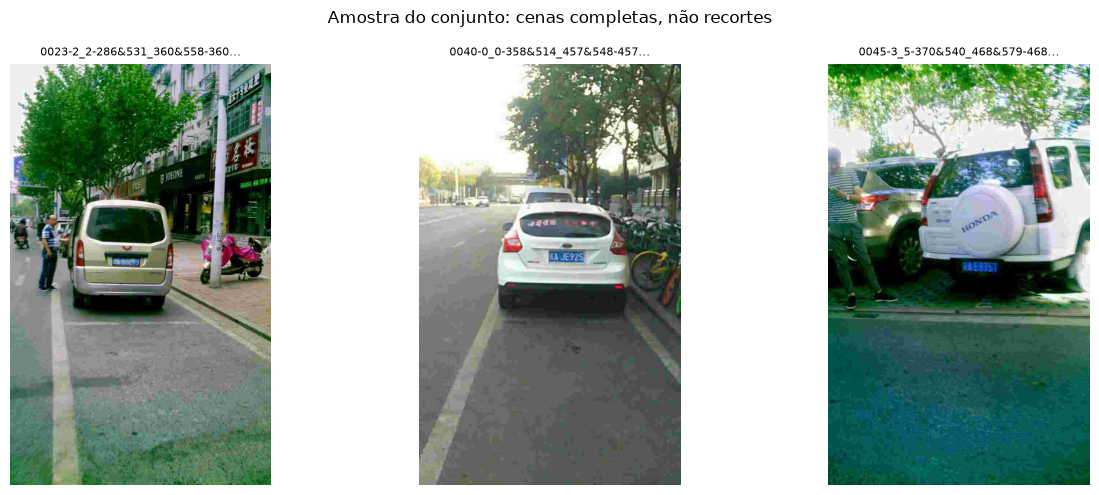

In [20]:
arquivos = sorted(CONFIG["raw_dir"].glob("*.jpg"))
print(f"Total de arquivos: {len(arquivos)}")

img = cv2.imread(str(arquivos[0]))
print(f"Dimensão (altura, largura, canais): {img.shape}")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, arq in zip(axes, arquivos[:3]):
    im = cv2.imread(str(arq))
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(arq.name[:28] + "...", fontsize=8)
    ax.axis("off")
fig.suptitle("Amostra do conjunto: cenas completas, não recortes")
fig.tight_layout(); plt.show()

### Premissas, restrições e critério de sucesso

#### Premissas heurísticas

Suposições que serão assumidas como verdadeiras:

i. A placa é o conteúdo relevante e todo o resto pode ser ignorado na estratégia de filtragem.
ii.  O sinal útil para o OCR é a diferença traço-fundo. As placas têm texto claro (branco) e fundo escuro (azul) e saturado. O OCR demanda esta separação preservada e amplificada
iii. Degradação na captura não significa ausência de conteúdo. Fotos com aparente má qualidade a olho humano (escuras, tortas, desfocadas), podem ter a sua informação atenuada, porém não ausente, que pode ser melhorada, salvo os casos em que ocorre saturação da imagem, onde a perda é definitiva.
iv. Os rótulos são confiáveis. As coordenadas e padrão de nomenclatura dos arquivos de imagens serão considerados como corretos.
v. É possível avaliar a qualidade sem precisar executar um processo de OCR. Basta considerar as propriedades que o OCR consome e as avaliar neste aspecto.

#### Restrições

* Deverá ser utilizado para o pré-processamento, apenas filtros lineares.
* Imagens não podem ser processadas ou editadas por meio de ferramentas de IA.
* As saídas devem gerar um arquivo .zip com a mesma quantidade e nome em relação as imagens originais.
* Todo o código, pipelines, análises e discussões devem ser autocontidos em um único notebook.
* O notebook deve ter a nomenclatura no formato Notebook vc_pratica1_<seu_nome>.ipynb , com as células já executadas.

#### Critérios de sucesso

Uma imagem estaria pronta para uso para este problema, se ao final do pipeline ela tiver:

* Geometria normalizada: Significa a placar estar frontal e com as dimensões padronizadas, para que os caracteres sejam compatíveis entre as imagens.
* Contraste suficiente: Traço e fundo com faixas de intensidade bem separadas.
* Bordas definidas: Transição nítida entre traço e fundo, sem borramento excessivo.
* Exposição utilizável: A imagem possui uma faixa razoável na escala de intensidade, sem colapsar no preto ou "estourar" no branco.

Logo, o pipeline deve ser capaz de:

* Aumentar até o valor ótimo a relação contraste traço-fundo em relação à entrada.
* Não degradar nenhuma imagem individualmente.
* Reduzir a dispersão do desempenho entre condições de captura.

**Métricas candidatas para avaliação:**


| Candidata | O que mede | Limitação |
|---|---|---|
| Variância do Laplaciano | energia de detalhe | escala com o contraste; confunde "mais claro" com "mais nítido" |
| Desvio-padrão da intensidade | dispersão global | não distingue contraste útil de ruído |
| Entropia do histograma | ocupação de níveis | ruído aumenta entropia sem melhorar legibilidade |
| **Contraste traço-fundo** | separação entre texto e placa | exige separar as duas populações |
| **Nitidez normalizada por contraste** | definição de borda, independente de exposição | menos difundida que a variância do Laplaciano |

Serão adotadas as duas últimas, formando uma métrica de **dois eixos**, justificado com mais detalhe na Parte 3.

**Escolha do pipeline vencedor:**

Será escolhido o pipeline que apresentar, nesta ordem de prioridade:
1 - Nenhuma imagem degradada (vale mais a robustez. Em produção, o custo de uma falha sistemática é maior que o benefício de uma média alta)
2 - Menor dispersão do desempenho entre condições de captura
3 - Maior ganho médio. 

### Boas práticas

De forma simplificada, adotaremos algumas boas práticas de Engenharia de Software e Engenharia de Dados.

#### Engenharia de software


| Prática | Falha que previne |
|---|---|
| **Configuração separada da execução** — toda parametrização no dicionário `CONFIG`, nenhuma constante solta nas células | pipeline que só reproduz se você lembrar quais números alterou e onde; resultado que não se sabe qual configuração gerou |
| **Funções puras** — entrada → saída, sem estado compartilhado entre chamadas | operador cujo resultado depende do que rodou antes, impossível de testar isoladamente |
| **Uma função, uma responsabilidade** | função que decodifica, valida e transforma ao mesmo tempo, e que precisa ser reescrita inteira quando um dos três muda |
| **Nomes que descrevem intenção** — `contraste_traco` em vez de `calc1` | código que exige releitura completa para ser entendido três semanas depois |
| **Falhar cedo e com mensagem clara** | erro que se manifesta longe da causa, onde o diagnóstico custa dez vezes mais |

**Separação entre medir e filtrar:**
A restrição dos filtros recai sobre a aplicação as imagens, não sobre ferramentas que avaliam o resultado. As funções que filtram e as funções que medem ficarão em blocos separados e identificados.

**Todo o código vive neste notebook:**

O entregável exige um notebook autocontido cujas saídas coincidam com o `.zip`, incluir módulos externos, em um `src/` põe em risco a reprodutibilidade deste projeto. A compensação é organizar o próprio notebook em camadas de configuração, operadores, pipeline, execução e análise, de modo que a estrutura que um pacote daria fique legível na ordem das células. Para um projeto pequeno e experimental, criar toda uma infraestrutura reprodutível é um investimento alto para a finalidade.

#### Engenharia de dados

| Prática | Falha que previne |
|---|---|
| **Separação entrada / saída** — `data/raw/` é imutável, `data/processed/` é regenerável | execução malfeita que corrompe os dados originais, sem cópia de recuperação |
| **Contrato de dados na ingestão** — validar dimensão, formato do nome e coordenadas ao carregar | `NaN` silencioso que só aparece na métrica final, sem rastro da origem |
| **Idempotência** — reexecutar produz exatamente o mesmo resultado | entrega que não confere com o notebook, violando requisito explícito do enunciado |
| **Caminhos relativos** | notebook que só roda na máquina de quem escreveu |
| **Semente fixa** (`SEED = 42`) | resultado que muda entre execuções sem que nada tenha mudado |
| **Rastreabilidade** — cada saída é atribuível ao arquivo de origem | imagem processada que não se sabe de onde veio |

### Filtros lineares e não lineares

Um filtro é **linear** quando satisfaz superposição e homogeneidade:

$$T(\alpha X + \beta Y) = \alpha\,T(X) + \beta\,T(Y)$$

Situações que levariam um filtro a ser não linear:
* Ordenação de valores com a vizinhança.
* Pesos que dependem do conteúdo da imagem.
* Existência de funções não lineares de intensidade.

**Tabelas comparativas por tipo de filtragem:**

#### Suavização

| Filtro | Como opera | Linear | Benefício | Limitação e custo |
|---|---|---|---|---|
| Média (caixa) | média aritmética da vizinhança | sim | muito barato; separável | borra bordas tanto quanto ruído |
| Gaussiano | média ponderada por peso gaussiano | sim | separável (2·k em vez de k² operações); resposta suave | atenua alta frequência sem distinguir borda de ruído |
| Mediana | valor central após ordenar a vizinhança | **não** | elimina ruído impulsivo preservando bordas | a ordenação quebra a linearidade; mais caro |
| Bilateral | pesa por proximidade **e** por similaridade de intensidade | **não** | excelente preservação de borda | peso depende do conteúdo, logo não é convolução; caro |

#### Realce e derivadas

| Filtro | Como opera | Linear | Aplicação neste projeto |
|---|---|---|---|
| Sobel / Prewitt | derivada primeira aproximada | sim | resposta ao contorno dos caracteres |
| Laplaciano | derivada segunda | sim | realce de detalhe; amplifica ruído junto |
| DoG / LoG | diferença de gaussianas | sim | isola uma banda de frequência espacial |
| *Unsharp mask* | `I + k·(I − G∗I)` | sim | realce de borda; apesar de composto, é combinação linear de operações lineares |

#### Manipulação de intensidade

| Operação | Forma | Linear | Situação nesta prática |
|---|---|---|---|
| Escala e deslocamento | `a·I + b` | sim | **principal ferramenta disponível** para corrigir exposição |
| Gama | `I^γ` | **não** | proibida — potência não preserva soma |
| Equalização / CLAHE | remapeia pela distribuição acumulada | **não** | proibidas — o mapeamento depende do histograma da imagem |
| Limiarização | `I > t` | **não** | proibida no pipeline; admissível na medição |

#### Discussão

Para este tipo de problema, os filtros gama, equalização e CLAHE são as ferramentas mais usuais para correção de exposição, que são não lineares e não podem ser utilziados. Restando apenas a operação de Escala e deslocamento. Por isto, a arquitetura deve considerar quais parâmetros serão escolhidos. A Análise Exploratória dos Dados irá trazer as informações que irão dar suporte a esta decisão.

### Análise exploratória do Dados - EDA

#### EDA para imagens

O objetivo da EDA é responder perguntas sobre o conteúdo dos dados presente. Diferentemente de uma EDA para dados tabulares, que possibilitam interpretações diretas a respeto da sua estrutura, no contexto de imagens, cada uma dela é uma matriz de pixel, onde o pixel é apenas um número.

**Para o contexto deste projeto, cada medida abaixo irá responder a uma pergunta de projeto:**

| Grupo | Medidas | Pergunta que responde |
|---|---|---|
| Anotação | área, inclinação, coordenadas, brilho e desfoque anotados | quanta variação o pipeline precisa absorver? |
| Exposição | média, desvio-padrão, percentis, amplitude | há sinal a recuperar, ou a informação foi perdida? |
| Saturação | fração de pixels em 0 e em 255 | a perda é reversível? |
| Contraste | separação entre traço e fundo | qual o ponto de partida do que queremos melhorar? |
| Nitidez | energia de gradiente, variância do Laplaciano | as bordas dos caracteres estão definidas? |
| Cor | presença do azul da placa, separação entre canais | o sinal cromático é aproveitável? |
| Geometria | escala da placa na cena, inclinações | um parâmetro fixo serve a todas as escalas? |

##### Metadados

Verifica-se a lógica na nomenclaruta dos arquivos (premissa iv) e extrai-se conclusões a respeito

In [21]:
nome = arquivos[0].stem
print(nome, "\n")
for i, campo in enumerate(nome.split("-")):
    print(f"campo {i}: {campo}")

0023-2_2-286&531_360&558-360&558_286&555_286&531_360&534-0_0_4_32_4_33_33-101-5 

campo 0: 0023
campo 1: 2_2
campo 2: 286&531_360&558
campo 3: 360&558_286&555_286&531_360&534
campo 4: 0_0_4_32_4_33_33
campo 5: 101
campo 6: 5


**Conclusões** São sete campos separados por hífen. O conjunto segue o padrão CCPD (Chinese City Parking Dataset), no qual o nome do arquivo é um registro estruturado:

| Campo | Conteúdo                                                |
|-------|---------------------------------------------------------|
| 0     | razão de área da placa × 10⁴                            |
| 1     | inclinação horizontal e vertical, em graus              |
| 2     | bounding box: canto superior-esquerdo e inferior-direito|
| 3     | os 4 vértices da placa                                  |
| 4     | texto da placa, codificado em índices                   |
| 5     | brilho anotado                                          |
| 6     | desfoque anotado                                        |



Este padrão da anotação traz um insight valioso. Além da localização, os 4 vértices descrevem o quadrilátero ocupado pela placa, o que viabiliza a normalização geométrica desta além do filtro. Campos de brilho e desfoque também são úteis.

In [22]:
# Confirmando esta hipótese

p = arquivos[0].stem.split("-")

razao_declarada = int(p[0]) / 10_000

lu, rd = p[2].split("_")
x1, y1 = map(int, lu.split("&"))
x2, y2 = map(int, rd.split("&"))

razao_calculada = ((x2 - x1) * (y2 - y1)) / (720 * 1160)

print(f"caixa           : {x2-x1} x {y2-y1} px")
print(f"razão calculada : {razao_calculada:.4%}")
print(f"razão declarada : {razao_declarada:.4%}")

caixa           : 74 x 27 px
razão calculada : 0.2392%
razão declarada : 0.2300%


A seguir, os 100 arquivos de imagens serão lidos e será gerada uma tabela com 100 linhas com metadados a respeito de cada imagem, possibilitando uma avaliação global do dataset, sua consistência e detectar anomalias.

O resultado será um arquivo tabular CSV para consultas, salvo na pasta data/interim/

In [23]:
def decodificar_nome(caminho: Path) -> dict:
    """Interpreta o nome de arquivo CCPD como registro estruturado."""
    campos = caminho.stem.split("-")
    if len(campos) != 7:
        raise ValueError(f"{caminho.name}: esperados 7 campos, obtidos {len(campos)}")

    tilt_h, tilt_v = (int(v) for v in campos[1].split("_"))

    lu, rd = campos[2].split("_")
    x1, y1 = (int(v) for v in lu.split("&"))
    x2, y2 = (int(v) for v in rd.split("&"))

    # ordem CCPD dos vértices: inf-dir, inf-esq, sup-esq, sup-dir
    vertices = [tuple(int(c) for c in v.split("&")) for v in campos[3].split("_")]
    if len(vertices) != 4:
        raise ValueError(f"{caminho.name}: esperados 4 vértices, obtidos {len(vertices)}")

    return {
        "arquivo":      caminho.name,
        "caminho":      caminho,
        "razao_area":   int(campos[0]) / 10_000,
        "tilt_h":       tilt_h,
        "tilt_v":       tilt_v,
        "bbox":         (x1, y1, x2, y2),
        "bbox_w":       x2 - x1,
        "bbox_h":       y2 - y1,
        "vertices":     vertices,
        "brilho_anot":  int(campos[5]),
        "desfoque_anot": int(campos[6]),
    }


def validar_registro(reg: dict, forma_img: tuple, tamanho_esperado: tuple) -> None:
    """Confere o registro decodificado contra a imagem carregada."""
    altura, largura = forma_img[:2]

    if (largura, altura) != tamanho_esperado:
        raise ValueError(f"{reg['arquivo']}: dimensão {(largura, altura)} "
                         f"difere da esperada {tamanho_esperado}")
    if reg["bbox_w"] <= 0 or reg["bbox_h"] <= 0:
        raise ValueError(f"{reg['arquivo']}: bounding box degenerado")
    for (vx, vy) in reg["vertices"]:
        if not (0 <= vx <= largura and 0 <= vy <= altura):
            raise ValueError(f"{reg['arquivo']}: vértice ({vx},{vy}) fora dos limites")

In [24]:
def carregar_indice(pasta: Path, tamanho_esperado: tuple) -> pd.DataFrame:
    caminhos = sorted(pasta.glob("*.jpg"))
    if not caminhos:
        raise FileNotFoundError(f"Nenhum .jpg encontrado em {pasta.resolve()}")

    registros, rejeitados = [], []
    for c in caminhos:
        try:
            reg = decodificar_nome(c)
            img = cv2.imread(str(c))
            if img is None:
                raise ValueError(f"{c.name}: falha ao decodificar a imagem")
            validar_registro(reg, img.shape, tamanho_esperado)
            registros.append(reg)
        except ValueError as e:
            rejeitados.append(str(e))

    if rejeitados:
        print(f"[ATENÇÃO] {len(rejeitados)} arquivo(s) rejeitado(s):")
        for r in rejeitados[:10]:
            print("   -", r)

    return pd.DataFrame(registros)


indice = carregar_indice(CONFIG["raw_dir"], CONFIG["expected_size"])
print(f"Imagens carregadas e validadas: {len(indice)} de 100\n")

indice[["arquivo", "razao_area", "tilt_h", "tilt_v",
        "bbox_w", "bbox_h", "brilho_anot", "desfoque_anot"]].head()

Imagens carregadas e validadas: 100 de 100



,arquivo,razao_area,tilt_h,tilt_v,bbox_w,bbox_h,brilho_anot,desfoque_anot
0,0023-2_2-286&531_360&558-360&558_286&555_286&5...,0.0023,2,2,74,27,101,5
1,0040-0_0-358&514_457&548-457&548_358&547_358&5...,0.0040,0,0,99,34,119,4
2,0045-3_5-370&540_468&579-468&579_371&573_370&5...,0.0045,3,5,98,39,43,2
3,0046-0_6-320&466_430&501-430&501_324&501_320&4...,0.0046,0,6,110,35,44,11
4,0047-0_1-285&527_389&565-389&565_286&565_285&5...,0.0047,0,1,104,38,85,6


In [27]:
def exportar_tabela(df: pd.DataFrame, caminho: Path, descartar=()) -> Path:
    """Exporta um DataFrame como CSV, descartando colunas não serializáveis."""
    cols = [c for c in df.columns if c not in descartar]
    caminho.parent.mkdir(parents=True, exist_ok=True)
    df[cols].to_csv(caminho, index=False, encoding="utf-8")
    print(f"[OK] {caminho.name}  ·  {len(df)} linhas × {len(cols)} colunas")
    return caminho


exportar_tabela(
    indice,
    CONFIG["interim_dir"] / "01_indice_anotacao.csv",
    descartar=("caminho", "bbox", "vertices"),
)

[OK] 01_indice_anotacao.csv  ·  100 linhas × 8 colunas


WindowsPath('../data/interim/01_indice_anotacao.csv')

#### Extração da região da placa

A placa possui a informação de interesse, mas ocupa apenas uma pequena porção de toda a imagem. Todo o resto é informação irrelevante (premissa i) e que só causa ruídos para a nossa filtragem e adoção da melhor estratégia de pré-processamento. Logo, o primeiro passo é isolar a região da placa antes de iniciarmos o nosso pré-processamento com filtros lineares.

Neste momento, há duas possibilidades de realizar esta operação:

**1 - Recorte por bounding box**:

Funciona usando os cantos superior-esquerdo e inferior-direito. Preserva a inclinação, assim, uma imagem fotografada em ângulo, continua inclinada dentro do recorte e o retângulo necessário incluiria outras informações nos cantos, que pode influenciar artificialmente a medida de contraste.

**2 - Retificação através dos 4 vértices:**

Será feita uma transformação da pespectiva que mapeia o quadrilátero ocupado por estes vértices (que contornam a placa), sempre com uma relação de tamanho fixa. O resultado é frontal, padronizado e sem ruídos adicionais.

Para fins didáticos, iremos testar as duas possibilidades e comparar os resultados:

In [28]:
def recortar_bbox(img: np.ndarray, bbox: tuple) -> np.ndarray:
    """Recorte retangular simples pelos cantos do bounding box."""
    x1, y1, x2, y2 = bbox
    return img[y1:y2, x1:x2]


def retificar_placa(img: np.ndarray, vertices: list, w: int, h: int) -> np.ndarray:
    """Mapeia o quadrilátero da placa para um retângulo w x h.

    A interpolação bilinear torna cada pixel de saída uma combinação linear
    ponderada dos vizinhos de entrada — linear em intensidade.
    """
    inf_dir, inf_esq, sup_esq, sup_dir = vertices          # ordem CCPD
    origem  = np.float32([sup_esq, sup_dir, inf_dir, inf_esq])
    destino = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    M = cv2.getPerspectiveTransform(origem, destino)
    return cv2.warpPerspective(img, M, (w, h), flags=cv2.INTER_LINEAR)

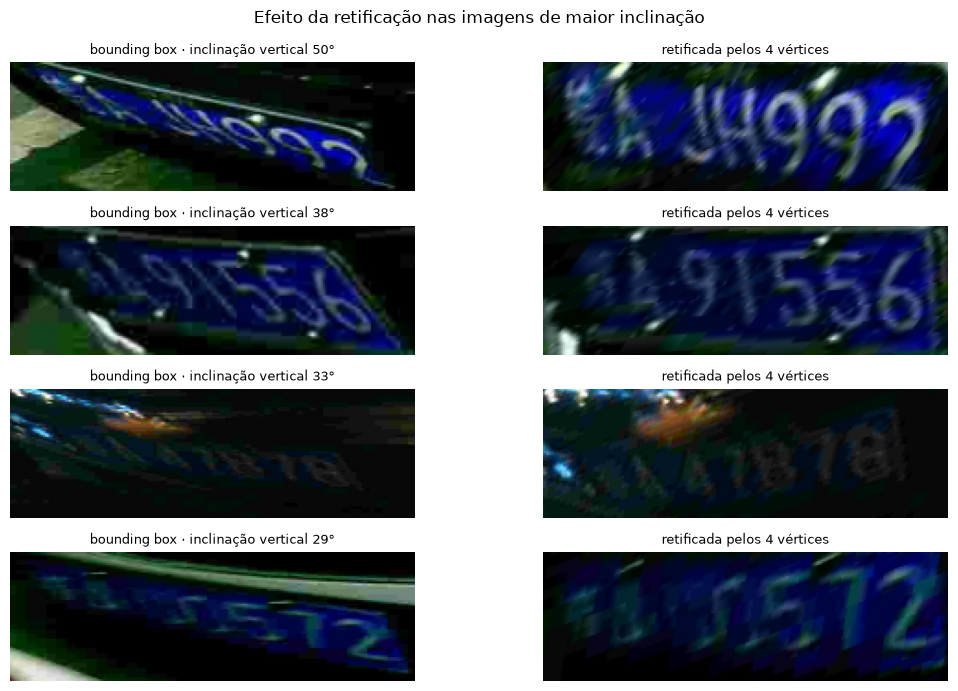

In [29]:
W, H = CONFIG["plate_w"], CONFIG["plate_h"]
mais_inclinadas = indice.nlargest(4, "tilt_v")

fig, axes = plt.subplots(4, 2, figsize=(11, 7))
for linha, (_, r) in zip(axes, mais_inclinadas.iterrows()):
    img = cv2.imread(str(r["caminho"]))
    versoes = [
        (cv2.resize(recortar_bbox(img, r["bbox"]), (W, H)),
         f"bounding box · inclinação vertical {r['tilt_v']}°"),
        (retificar_placa(img, r["vertices"], W, H),
         "retificada pelos 4 vértices"),
    ]
    for ax, (im, titulo) in zip(linha, versoes):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(titulo, fontsize=9)
        ax.axis("off")

fig.suptitle("Efeito da retificação nas imagens de maior inclinação", fontsize=12)
fig.tight_layout(); plt.show()

**Conclusões:**

A retificação a q4uatro vértices demonstra visualmente resultados superiores. Ela entrega geometria normalizada: placa frontal, em escala fixa e com caracteres possíveis de serem comparados entre imagens.

#### Extração das medidas e construção do quadro analítico

Abaixo, as medidas a serem avaliadas, o que captura e pergunta que responde:

| Medida | O que captura | Decisão que informa |
|---|---|---|
| `media`, `desvio` | nível e dispersão da intensidade | há sinal a recuperar? |
| `p1`, `p99`, `amplitude` | faixa efetivamente ocupada da escala | quanto a normalização pode expandir? |
| `sat_baixa`, `sat_alta` | pixels colados em 0 e em 255 | a perda é reversível? |
| `entropia` | quantos níveis distintos a imagem usa | há estrutura ou apenas ruído? |
| `contraste` | separação média entre traço e fundo | ponto de partida do que queremos melhorar |
| `lap_var`, `grad_medio` | energia de detalhe e de borda | as bordas dos caracteres estão definidas? |
| `frac_azul`, `b_menos_r` | presença e força do azul da placa | o croma é aproveitável como sinal? |


**Observação:** Algumas destas medições utilizam operações não lineares, porém não violam a restrição de usar somente filtros lineares, pois estes são para transformações do pré-processamento, já estes, são para medição exploratória.

In [30]:
# =============================================================================
# INSTRUMENTOS DE MEDIÇÃO
# Estas funções MEDEM, não filtram. Podem usar operações não-lineares.
# Os operadores do pipeline (Parte 2) obedecem à restrição de linearidade.
# =============================================================================

def para_cinza(bgr: np.ndarray) -> np.ndarray:
    """Converte para escala de cinza em ponto flutuante."""
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)


def contraste_traco(g: np.ndarray) -> float:
    """Separação média entre traço e fundo, normalizada para [0, 1].

    Usa o limiar de Otsu para particionar a imagem em duas populações e
    devolve a diferença entre as médias. Limitada por construção.
    """
    g8 = np.clip(g, 0, 255).astype(np.uint8)
    limiar, _ = cv2.threshold(g8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    traco = g8 > limiar
    if traco.sum() == 0 or traco.sum() == traco.size:
        return 0.0
    return float((g8[traco].mean() - g8[~traco].mean()) / 255.0)

In [31]:
def medir(bgr: np.ndarray) -> dict:
    """Extrai todas as medidas de uma imagem de placa."""
    g  = para_cinza(bgr)
    g8 = np.clip(g, 0, 255).astype(np.uint8)

    p1, p99 = np.percentile(g, [1, 99])

    hist = cv2.calcHist([g8], [0], None, [256], [0, 256]).ravel()
    p = hist / hist.sum()
    p = p[p > 0]

    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    matiz, satur = hsv[:, :, 0].astype(float), hsv[:, :, 1].astype(float)
    azul = ((matiz >= 100) & (matiz <= 130) & (satur > 60)).astype(np.float32)

    b, _, r = cv2.split(bgr.astype(np.float32))

    return {
        "media":      float(g.mean()),
        "desvio":     float(g.std()),
        "p1":         float(p1),
        "p99":        float(p99),
        "amplitude":  float(p99 - p1),
        "sat_baixa":  float((g <= 5).mean()),
        "sat_alta":   float((g >= 250).mean()),
        "entropia":   float(-(p * np.log2(p)).sum()),
        "contraste":  contraste_traco(g),
        "lap_var":    float(cv2.Laplacian(g, cv2.CV_32F).var()),
        "grad_medio": float(np.sqrt(gx**2 + gy**2).mean()),
        "frac_azul":  float(azul.mean()),
        "b_menos_r":  float((b - r).mean()),
    }

In [32]:
medidas = []
for _, r in indice.iterrows():
    img = cv2.imread(str(r["caminho"]))

    retificada = retificar_placa(img, r["vertices"], W, H)
    recortada  = cv2.resize(recortar_bbox(img, r["bbox"]), (W, H))

    linha = {"arquivo": r["arquivo"]}
    linha.update(medir(retificada))
    linha.update({f"bbox_{k}": v for k, v in medir(recortada).items()})
    medidas.append(linha)

eda = indice.merge(pd.DataFrame(medidas), on="arquivo")
print(f"Quadro analítico: {len(eda)} linhas × {len(eda.columns)} colunas\n")

colunas_principais = ["media", "desvio", "amplitude", "sat_baixa", "sat_alta",
                      "entropia", "contraste", "lap_var", "grad_medio",
                      "frac_azul", "b_menos_r"]
eda[colunas_principais].describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]].round(3)

Quadro analítico: 100 linhas × 37 colunas



,min,25%,50%,75%,max,mean,std
media,12.410,24.234,62.398,125.111,228.178,85.356,68.361
desvio,5.008,11.805,22.355,27.761,84.843,22.741,14.244
amplitude,21.000,49.000,92.000,123.750,230.000,93.451,48.857
sat_baixa,0.000,0.000,0.000,0.001,0.336,0.011,0.046
sat_alta,0.000,0.000,0.000,0.000,0.126,0.005,0.018
entropia,2.053,4.249,5.637,6.393,7.375,5.327,1.321
contraste,0.045,0.084,0.152,0.213,0.690,0.174,0.121
lap_var,19.001,28.293,43.112,62.089,720.092,106.600,156.027
grad_medio,9.795,21.520,33.138,47.115,116.225,36.104,18.611
frac_azul,0.000,0.153,0.509,0.850,1.000,0.505,0.346


In [33]:
exportar_tabela(
    eda,
    CONFIG["interim_dir"] / "02_quadro_analitico.csv",
    descartar=("caminho", "bbox", "vertices"),
)

[OK] 02_quadro_analitico.csv  ·  100 linhas × 34 colunas


WindowsPath('../data/interim/02_quadro_analitico.csv')

#### Distribuições

As estatísticas do quadro anterior exibiram as estatísticas descritivas, que indicaram uma dispersão elevada, porém, não mostram a forma de como é a distribuição. Para uma mesma média e desvio, podemos ter distribuições diferentes, exibindo diferentes agrupamentos. Enxergar esta forma traz valor para decidir a arquitetura do pipeline. 

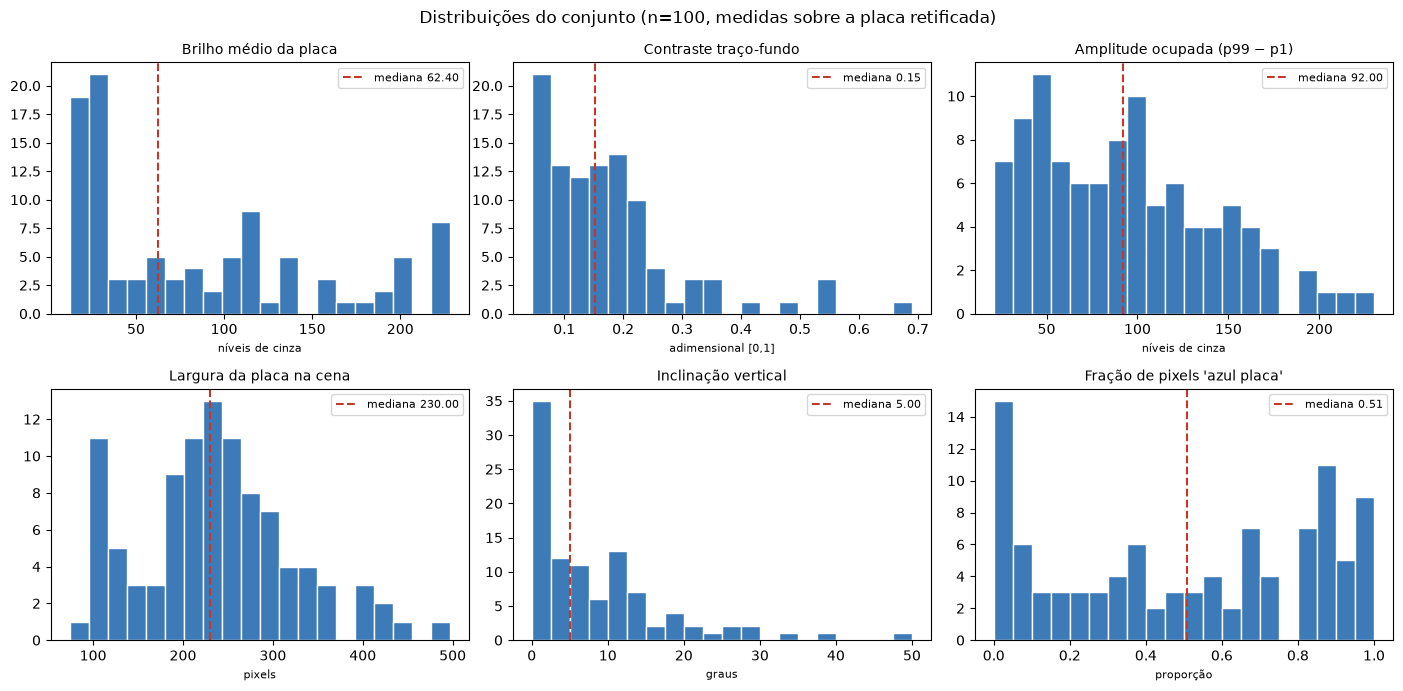

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

especificacoes = [
    ("media",     "Brilho médio da placa",         "níveis de cinza"),
    ("contraste", "Contraste traço-fundo",         "adimensional [0,1]"),
    ("amplitude", "Amplitude ocupada (p99 − p1)",  "níveis de cinza"),
    ("bbox_w",    "Largura da placa na cena",      "pixels"),
    ("tilt_v",    "Inclinação vertical",           "graus"),
    ("frac_azul", "Fração de pixels 'azul placa'", "proporção"),
]

for ax, (col, titulo, unidade) in zip(axes.ravel(), especificacoes):
    ax.hist(eda[col], bins=20, color="#3d7ab8", edgecolor="white")
    ax.axvline(eda[col].median(), color="#c0392b", ls="--", lw=1.5,
               label=f"mediana {eda[col].median():.2f}")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(unidade, fontsize=8)
    ax.legend(fontsize=8)

fig.suptitle("Distribuições do conjunto (n=100, medidas sobre a placa retificada)",
             fontsize=12)
fig.tight_layout(); plt.show()

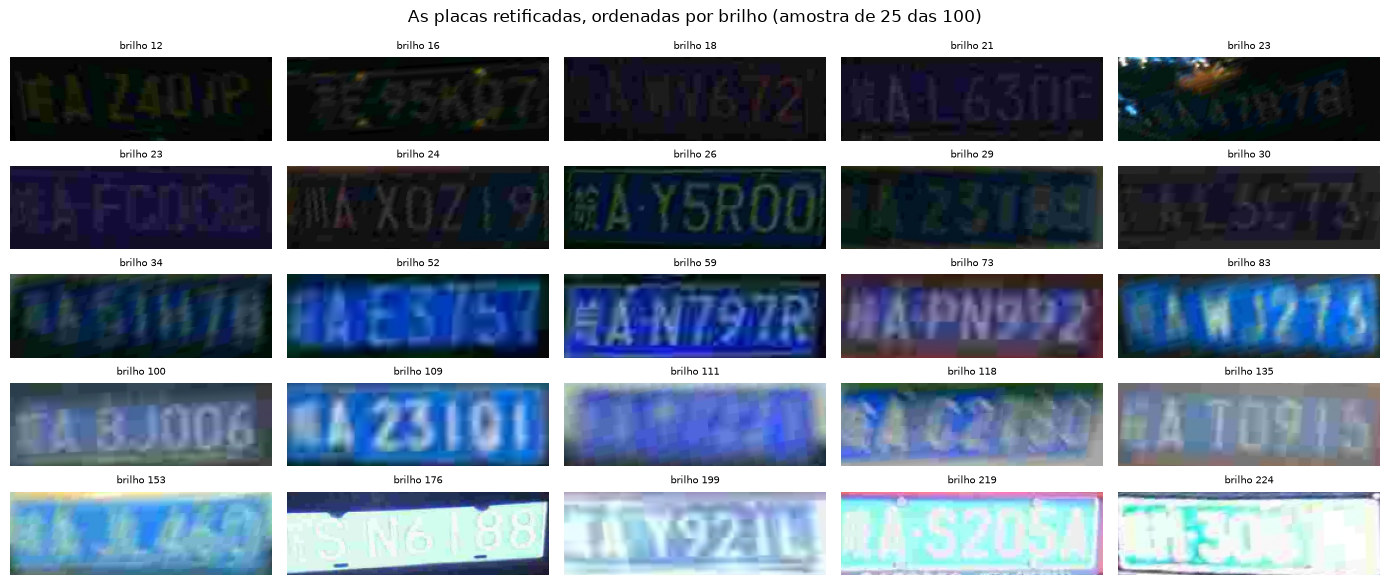

In [35]:
ordenado = eda.sort_values("media").reset_index(drop=True)
amostra = ordenado.iloc[::4]                     # 25 imagens ao longo da faixa

fig, axes = plt.subplots(5, 5, figsize=(14, 6))
for ax, (_, r) in zip(axes.ravel(), amostra.iterrows()):
    img = cv2.imread(str(r["caminho"]))
    ax.imshow(cv2.cvtColor(retificar_placa(img, r["vertices"], W, H),
                           cv2.COLOR_BGR2RGB))
    ax.set_title(f"brilho {r['media']:.0f}", fontsize=7)
    ax.axis("off")

fig.suptitle("As placas retificadas, ordenadas por brilho (amostra de 25 das 100)",
             fontsize=12)
fig.tight_layout(); plt.show()

**Interpretação**

* Brilho: Não é unimodal e exibe agrupamentos. Pode-se supor tratar-se de dia e noite.
* Azul: A fração azul (fundo da placa) é bimodal. Uma estratégia baseada em cor pode ser frágil quando ocorrerem imagens difíceis.
* Largura da placa: Varia de 80 a 500px, fator de quase 6. Um σ de suavização pode preservar o traço na de 500 mas apagar no de 80px.Logo, o parâmetro σ deve acompanhar a escala.
* Nitidez e exposição são eixos independentes: Algumas placas ficam escuras, outras muito claras. Sendo a legibilidade do texto independente desta intensidade.

#### Relações entre variáveis

Até agora, verificamos as variáveis isoladamente. Mas se duas medidas variarem juntas, esta informação pode ser condensada e irá nos guiar nas decisões das features a serem utilizadas.

**Responderemos as seguintes perguntas:**

1- Um sinal cromático (cor e saturação) se comporta igual em todas as exposições?
2- As medidas usuais de nitidez são independentes do brilho?

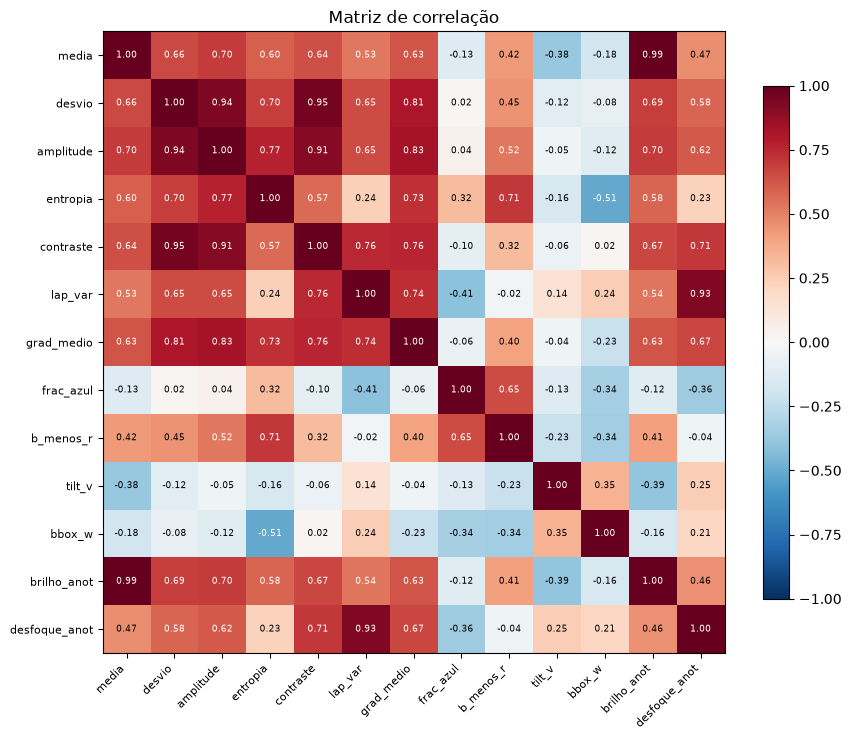

In [40]:
variaveis = ["media", "desvio", "amplitude", "entropia", "contraste",
             "lap_var", "grad_medio", "frac_azul", "b_menos_r",
             "tilt_v", "bbox_w", "brilho_anot", "desfoque_anot"]

corr = eda[variaveis].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variaveis)))
ax.set_xticklabels(variaveis, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(variaveis)))
ax.set_yticklabels(variaveis, fontsize=8)

for i in range(len(variaveis)):
    for j in range(len(variaveis)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=6.5, color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Matriz de correlação", fontsize=12)
fig.tight_layout(); plt.show()

In [41]:
print("Correlação de cada medida com o brilho médio:\n")
print(corr["media"].drop("media").sort_values(ascending=False).round(3).to_string())

Correlação de cada medida com o brilho médio:

brilho_anot      0.993
amplitude        0.701
desvio           0.662
contraste        0.645
grad_medio       0.632
entropia         0.597
lap_var          0.531
desfoque_anot    0.468
b_menos_r        0.422
frac_azul       -0.126
bbox_w          -0.183
tilt_v          -0.377


In [42]:
quintil = pd.qcut(eda["media"], 5,
                  labels=["q1 escuro", "q2", "q3", "q4", "q5 claro"])

print(eda.groupby(quintil, observed=True).agg(
    n=("arquivo", "count"),
    brilho=("media", "mean"),
    frac_azul=("frac_azul", "mean"),
    b_menos_r=("b_menos_r", "mean"),
    contraste=("contraste", "mean"),
    lap_var=("lap_var", "mean"),
).round(2).to_string())

            n  brilho  frac_azul  b_menos_r  contraste  lap_var
media                                                          
q1 escuro  20   18.89       0.30       8.65       0.10    74.30
q2         20   27.39       0.46      17.95       0.09    48.76
q3         20   64.83       0.76      57.14       0.17    65.84
q4         20  117.08       0.74      75.04       0.20    40.54
q5 claro   20  198.60       0.27      53.14       0.31   303.56


In [45]:
from scipy.stats import pearsonr, spearmanr

# relação linear vs. monotônica: se o croma fosse monotônico no brilho,
# ambas seriam altas. O contraste entre elas revela a forma de sino.
for var in ["b_menos_r", "frac_azul"]:
    p, _ = pearsonr(eda["media"], eda[var])
    s, _ = spearmanr(eda["media"], eda[var])
    print(f"{var:12} | Pearson {p:+.3f} | Spearman {s:+.3f}")

# e o teste direto: comparar as pontas contra o miolo
pontas = eda[(eda["media"] < 30) | (eda["media"] > 180)]["b_menos_r"].mean()
miolo  = eda[(eda["media"] >= 30) & (eda["media"] <= 180)]["b_menos_r"].mean()
print(f"\nb_menos_r nas pontas (escuras + claras): {pontas:.1f}")
print(f"b_menos_r no miolo                     : {miolo:.1f}")

b_menos_r    | Pearson +0.422 | Spearman +0.617
frac_azul    | Pearson -0.126 | Spearman +0.063

b_menos_r nas pontas (escuras + claras): 21.6
b_menos_r no miolo                     : 64.9


**Interpretação:**

Temos as seguintes conclusões

i. Correlação de 0,993 entre brilho_anot e a média medida. útil para validar o pipeline de ingestão.
ii. O rótulo de desfoque da nomenclatura do CCPD é, na prática, a variância do Laplaciano. Correlação de 0,93 entre desfoque_anot e lap_var. Serve como referência externa na Parte 3.
iii. Desvio, amplitude e contraste correlacionam entre 0,91 e 0,95. Podem ser reduzidos a um único eixo. Usar as três na métrica contaria o mesmo fenômeno três vezes.
iv. Medidas de nitidez estão contaminadas pela exposição. lap_var correlaciona 0,53 com o brilho e salta de ~40–74 nos quintis intermediários para 303 no quintil claro. Ela escala com o contraste, não com o foco. Qualquer métrica de nitidez precisará ser normalizada.
v. O croma colapsa nas duas pontas. É um achado relevante. A separação B−R vale 21,6 nas imagens muito escuras ou muito claras, contra 64,9 no centro. Nas 20 mais escuras cai para 8,6 níveis, dentro do ruído JPEG. Uma estratégia baseada em cor funcionaria nas imagens fáceis e falharia nas difíceis. O Croma pode entrar com peso moderado, mas nunca como o mecanismo principal.


### Diagnóstico e direcionamentos

As análises realizadas dizem sobre o conjunto, mas não sobre o teto da solução e o quanto da degradação detectada é reversível. 

As análises levaram a 3 diagnósticos fundamentais que irão determinar a arquitetura da solução.

#### Diagnóstico 1: Há problema de subexposição, mas que é reversível

O conjunto não tem uma variedade equilibrada de iluminação. Verifica-se a assimetria entre as duas caudas.


In [50]:
# --- Diagnóstico 1a: assimetria entre as caudas ------------------------------

print("Brilho médio da placa")
print(f"  mín {eda['media'].min():.0f} | mediana {eda['media'].median():.0f} "
      f"| máx {eda['media'].max():.0f}\n")

print(f"Imagens muito escuras (brilho < 30) ....... {(eda['media'] < 30).sum():3d} / 100")
print(f"Imagens muito claras  (brilho > 180) ...... {(eda['media'] > 180).sum():3d} / 100")
print()
print(f"Com >2% dos pixels na faixa 0–5 ........... {(eda['sat_baixa'] > 0.02).sum():3d} / 100")
print(f"Com >2% dos pixels em 255 ................. {(eda['sat_alta']  > 0.02).sum():3d} / 100")

Brilho médio da placa
  mín 12 | mediana 62 | máx 228

Imagens muito escuras (brilho < 30) .......  37 / 100
Imagens muito claras  (brilho > 180) ......  15 / 100

Com >2% dos pixels na faixa 0–5 ...........  11 / 100
Com >2% dos pixels em 255 .................   7 / 100


Testou-se a coluna sat_baixa definida como a fração de pixels com valor até 5, não exatamente zero. Essa escolha foi conservadora para detectar imagens problemáticas, mas não serve para medir perda irreversível: uma faixa de 0 a 5 admite variação, e variação é sinal.

In [51]:
# --- Diagnóstico 1b: perda irreversível vs. sinal atenuado -------------------
# Zero absoluto é perda definitiva: a*0 + b devolve constante.
# Pixels entre 1 e 5 ainda carregam variação, portanto sinal recuperável.

print("Perda irreversível nas imagens mais afetadas\n")
print(f"{'arquivo':<26} | {'g==0':>7} | {'g<=5':>7} | {'desvio se 0<g<=5':>17}")
print("-" * 68)

for _, r in eda.nlargest(5, "sat_baixa").iterrows():
    g = para_cinza(retificar_placa(cv2.imread(str(r["caminho"])),
                                   r["vertices"], W, H))
    residual = g[(g > 0) & (g <= 5)]
    dp = residual.std() if residual.size > 10 else float("nan")
    print(f"{r['arquivo'][:24]:<26} | {(g == 0).mean():>6.1%} "
          f"| {(g <= 5).mean():>6.1%} | {dp:>17.3f}")

Perda irreversível nas imagens mais afetadas

arquivo                    |    g==0 |    g<=5 |  desvio se 0<g<=5
--------------------------------------------------------------------
0312-2_28-212&462_526&54   |  16.8% |  33.6% |             1.635
0208-1_10-245&440_468&51   |   8.4% |  25.7% |             1.515
0812-19_29-259&475_582&6   |   8.9% |  16.4% |             1.398
0065-7_0-365&480_472&531   |   0.3% |   5.1% |             1.405
0483-0_10-159&510_507&62   |   2.4% |   4.9% |             1.406


Na pior imagem do conjunto, 33,6% dos pixels estão na faixa 0–5, mas apenas 16,8% em zero absoluto, ou seja, metade da região aparentemente perdida ainda carrega sinal. Nas outras a perda cai para menos de 9%, e em dois casos para menos de 3%. O desvio de aproximadamente 1,4 a 1,6 níveis entre os pixels de valor 1 a 5 confirma que há variação real nessa região. É pouco,mas é um ganho a recuperar mas que junto com um pouco de ruído.

#### Diagnóstico 2: O sinal cromático colapsa nas duas pontas

Estabelecido na anterior e retomado aqui pela sua consequência.

| Regime | n | separação B−R |
|---|---|---|
| pontas (brilho < 30 ou > 180) | 35 | **21,6** |
| miolo (30 ≤ brilho ≤ 180) | 65 | **64,9** |

Nas 20 imagens mais escuras a separação cai para 8,6 níveis, que fica no piso do ruído de compressão JPEG. Nas escuras falta luz para distinguir canais e nas claras a saturação lava a cor.

**Consequência de projeto:** 

Uma combinação linear de canais que explore o azul da placa é possível, teria desempenho excelente nas imagens fáceis, mas falharia nas que constituem o problema. O croma entra com peso moderado, não como mecanismo principal.

#### Diagnóstico 3: As medidas usuais de nitidez respondem à exposição

Este diagnóstico é sobre a **métrica**, não sobre o pipeline. A variância do Laplaciano é a medida de nitidez mais difundida. O problema é que o Laplaciano é
linear: multiplicar a imagem por um ganho `a` multiplica sua resposta por `a`, e a **variância por a²**. Uma imagem escura clareada por um fator 3 exibe variância nove vezes maior sem que uma única borda tenha ficado mais definida.

O experimento abaixo separa as duas situações que uma métrica de nitidez precisa distinguir: **(A)** a imagem apenas escalada, sem nenhum realce; **(B)** as bordas genuinamente degradadas por desfoque.Uma medida útil precisa ficar em silêncio no primeiro caso e reagir no segundo.

In [52]:
# --- Diagnóstico 3: exposição não é nitidez ----------------------------------

def nitidez_normalizada(g: np.ndarray) -> float:
    """Energia de gradiente dividida pelo desvio-padrão da imagem.

    Numerador e denominador escalam juntos sob ganho, de modo que a razão é
    invariante a transformações de intensidade: mede definição de borda,
    não exposição.
    """
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    return float(np.sqrt(gx**2 + gy**2).mean() / (g.std() + 1e-6))


exemplo = eda.nsmallest(1, "media").iloc[0]
g = para_cinza(retificar_placa(cv2.imread(str(exemplo["caminho"])),
                               exemplo["vertices"], W, H))

print("A) GANHO PURO — a imagem é escalada; nenhuma borda é realçada")
print(f"{'ganho':>7} | {'var. Laplaciano':>16} | {'nitidez normalizada':>20}")
print("-" * 50)
for a in [1, 2, 3, 5]:
    print(f"{a:>7} | {cv2.Laplacian(a*g, cv2.CV_32F).var():>16.1f} "
          f"| {nitidez_normalizada(a*g):>20.4f}")

print("\nB) DESFOQUE GAUSSIANO — as bordas são realmente degradadas")
print(f"{'sigma':>7} | {'var. Laplaciano':>16} | {'nitidez normalizada':>20}")
print("-" * 50)
for s in [0, 1, 2, 3]:
    gb = cv2.GaussianBlur(g, (0, 0), s) if s > 0 else g
    print(f"{s:>7} | {cv2.Laplacian(gb, cv2.CV_32F).var():>16.1f} "
          f"| {nitidez_normalizada(gb):>20.4f}")

A) GANHO PURO — a imagem é escalada; nenhuma borda é realçada
  ganho |  var. Laplaciano |  nitidez normalizada
--------------------------------------------------
      1 |             22.8 |               1.7460
      2 |             91.1 |               1.7460
      3 |            205.1 |               1.7460
      5 |            569.7 |               1.7460

B) DESFOQUE GAUSSIANO — as bordas são realmente degradadas
  sigma |  var. Laplaciano |  nitidez normalizada
--------------------------------------------------
      0 |             22.8 |               1.7460
      1 |              2.2 |               1.5487
      2 |              0.4 |               1.2872
      3 |              0.1 |               1.0797


**Interpretação:**

Em (A) nada foi realçado, mas a variância do Laplaciano cresce por um fator 25 ao passar de ganho 1 para ganho 5, isto é 5². A nitidez normalizada permanece em
1,7460, # para uma imagem que não mudou de nitidez.

Em (B) as bordas foram efetivamente degradadas, e ambas as medidas caem. A diferença é que apenas a segunda havia permanecido em discreta no caso anterior e "uma medida que reage a tudo não informa nada".

Vale notar que a contaminação atinge também a referência externa: o rótulo de desfoque do CCPD correlaciona 0,93 com a variância do Laplaciano e 0,47 com o brilho médio. Isso não o invalida, mas exige tratá-lo como referência de viés conhecido na Parte 3, não como verdade absoluta.

**Consequência de projeto:** 

Qualquer métrica de nitidez precisa ser normalizada por contraste, sob pena de reportar que clarear uma imagem a deixou mais nítida. A construção formal da
métrica é o primeiro item da Parte 2 deliberadamente antes do pipeline, porque sem instrumento a calibração se reduz a impressão visual, que é o viés que esta prática existe para eliminar.

#### Súmula

| Diagnóstico | Consequência de projeto |
|---|---|
| Subexposição dominante e majoritariamente reversível | A alavanca principal é a normalização afim de intensidade |
| Croma colapsa nas pontas | A combinação de canais entra com peso moderado, não como mecanismo principal |
| Nitidez usual contaminada pela exposição | A métrica de nitidez é normalizada por contraste |
| Escala da placa varia por fator 6 (80 a 500 px) | Parâmetros dependentes de escala acompanham a dimensão da placa |
| Medidas de contraste dependem do enquadramento | A linha de base da avaliação é a mesma imagem retificada, antes e depois |
| `desvio`, `amplitude` e `contraste` são redundantes | A métrica usa um eixo de contraste, não três |

Essas seis linhas irão influenciar diretamente na arquitetura.

## Proposta de solução

Antes de se propor a arquitertura da solução, devemos resgatar umas das perguntas provocadas para este problema:

*"um pipeline serve a todas as imagens?"*

Mas que poderia derivar duas intepretações:

Opção 1 - Uma única topologia serve a todas? (os mesmos blocos, na mesma ordem)
Opção 2 - Um único conjunto de parâmetros serve a todas? (os mesmos números para todas as imagens)

Vamos verificar:




In [66]:
# --- Parâmetros fixos vs. estimados por imagem -------------------------------
# Medida provisória (contraste traço-fundo). A métrica formal vem na Parte 2.

def normalizar_afim(g: np.ndarray, pct_lo: float, pct_hi: float) -> np.ndarray:
    """Escala e desloca para ocupar a faixa completa: a*I + b.

    Os percentis são MEDIDOS da imagem; o operador APLICADO aos pixels é afim.
    """
    lo, hi = np.percentile(g, [pct_lo, pct_hi])
    hi = max(hi, lo + 1.0)
    return ((g - lo) * (255.0 / (hi - lo))).astype(np.float32)


linhas = []
for _, r in eda.iterrows():
    g = para_cinza(retificar_placa(cv2.imread(str(r["caminho"])),
                                   r["vertices"], W, H))
    linhas.append({
        "arquivo":     r["arquivo"],
        "entrada":     contraste_traco(g),
        "param_fixo":  contraste_traco(2.5 * g - 40.0),
        "param_local": contraste_traco(normalizar_afim(g, CONFIG["pct_lo"],
                                                          CONFIG["pct_hi"])),
    })

teste = pd.DataFrame(linhas).merge(eda[["arquivo", "media"]], on="arquivo")
teste["quintil"] = pd.qcut(teste["media"], 5,
                           labels=["q1 escuro", "q2", "q3", "q4", "q5 claro"])

por_quintil = teste.groupby("quintil", observed=True)[
    ["entrada", "param_fixo", "param_local"]].mean().round(3)
print(por_quintil.to_string())

print(f"\n{'':14}{'média':>9}{'desvio entre quintis':>23}{'degradadas':>13}")
for col, rot in [("entrada", "entrada"), ("param_fixo", "parâmetro fixo"),
                 ("param_local", "por imagem")]:
    pior = 0 if col == "entrada" else int((teste[col] < teste["entrada"]).sum())
    print(f"{rot:<14}{teste[col].mean():>9.3f}"
          f"{por_quintil[col].std():>23.3f}{pior:>13d}")

           entrada  param_fixo  param_local
quintil                                    
q1 escuro    0.099       0.224        0.441
q2           0.092       0.222        0.434
q3           0.167       0.377        0.415
q4           0.195       0.304        0.442
q5 claro     0.315       0.326        0.506

                  média   desvio entre quintis   degradadas
entrada           0.174                  0.090            0
parâmetro fixo    0.290                  0.067           14
por imagem        0.447                  0.034            0


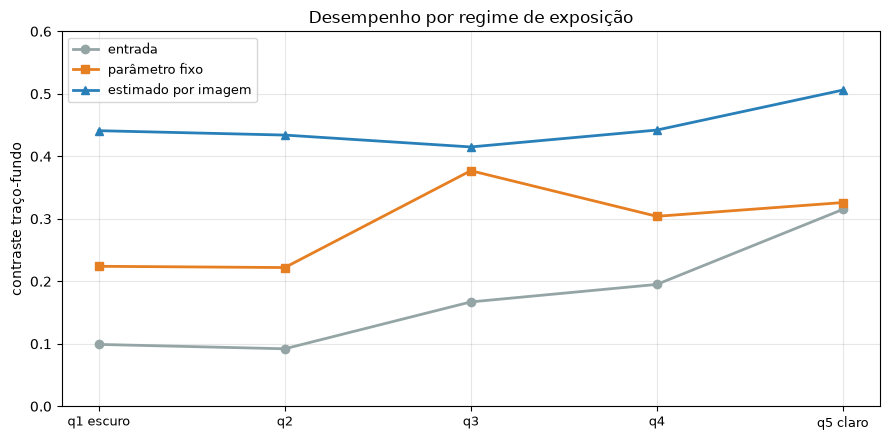

In [54]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(5)
for col, cor, mk, rot in [("entrada", "#95a5a6", "o", "entrada"),
                          ("param_fixo", "#e67e22", "s", "parâmetro fixo"),
                          ("param_local", "#2980b9", "^", "estimado por imagem")]:
    ax.plot(x, por_quintil[col], marker=mk, color=cor, lw=2, label=rot)
ax.set_xticks(x); ax.set_xticklabels(por_quintil.index, fontsize=9)
ax.set_ylabel("contraste traço-fundo"); ax.set_ylim(0, 0.6)
ax.set_title("Desempenho por regime de exposição")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Interpretação:**

| | média | desvio entre quintis | imagens degradadas |
|---|---|---|---|
| entrada | 0,174 | 0,090 | — |
| parâmetro fixo | 0,290 | 0,067 | **14** |
| parÂmetro estimado por imagem | **0,447** | **0,034** | **0** |

Um parâmetro fixo piora 14 imagens (14% do total). Se for estimado por imagem, nenhuma. Isto já elimina a opção 2.

**Logo, uma única topologia poderia servir às 100 imagens (não significa que seria a melhor), mas um único conjunto de parâmetros, não ajudaria.**


Para responder se uma topologia única seria a melhor escolha, iremos criar duas arquiteturas, ambas partem da mesma base: retificação pelos 4 vértices, redução a um canal escalar e normalização afim com parâmetros estimados por imagem. Diferenciando-se em como tratam o realce de borda.

### Pipeline A: Cadeia sequencial

**Sequência:**

`retificação → combinação linear de canais → suavização gaussiana → unsharp mask → normalização afim`

Arquitetura clássica em cascata, em que cada etapa recebe a saída da anterior. A suavização usa σ proporcional à largura da placa, atendendo à variação de escala por fator 6 identificada na EDA.

**Caracteriza-se por:** 

Simplicidade, poucos parâmetros, comportamento previsível. O realce é controlado por um único ganho `k` no unsharp mask.

**Limitação esperada:** 

Trata ruído e detalhe como um único fenômeno. Suavizar para reduzir ruído atenua também o traço do caractere. Realçar para recuperar o traço reamplifica o ruído. A cadeia não separa os dois.

#### Pipeline B: Decomposição multiescala

`retificação → combinação linear de canais → decomposição em bandas (DoG) → recombinação ponderada → normalização afim`

Em vez de encadear operações, se decompõe a imagem em bandas de frequência espacial por diferenças gaussianas e as recombina com pesos: `saída = Σ wᵢ · bandaᵢ`. É linear e generalização do unsharp mask, que é o caso particular de duas bandas.

**Caracteriza-se por:**

Permitir amplificar a banda onde vive o traço do caractere e em atenuar separadamente aquela onde há o ruído de compressão. É a separação no qual a cadeia sequencial não faz.

**Limitação esperada:** 

Mais parâmetros para calibrar e risco de ajuste excessivo para as 100 imagens.


#### Ordem de implantação

1. **Pipeline A**, como linha de base funcional
2. **Pipeline B**, mantendo A como controle e comparação
3. Comparação sob a métrica esclhida e escolha do pipeline vencedor para produção



#### Como avaliar o sucesso

Resgatando o critério estabelecido para avaliação, nesta ordem de prioridade:

1. **Nenhuma imagem degradada** em relação à entrada
2. **Menor dispersão** do desempenho entre regimes de captura
3. **Maior ganho médio**

A avaliação irá usar métrica de dois eixos, para contraste traço-fundo e nitidez normalizada, medindo sempre a **mesma imagem retificada, antes e depois da filtragem**, conforme a nota metodológica estabelecida na sessão anterior

## Parte 2 - Implementação

### Protocolo de Pré-processamento

Ambos os pipelines A e B seguirão o mesmo protocolo de entrada e saída, se diferenciando apenas no tratamento do realce.

**A tabela abaixo mostra as etapas comuns e sua justificativa:**

| # | Etapa | Justificativa |
|---|---|---|
| 1 | Retificação pelos 4 vértices | geometria normalizada |
| 2 | Conversão para `float32` | evita estouro e preserva valores negativos |
| 3 | Redução a canal escalar | combinação linear de canais, com croma de peso moderado (diagnóstico 2) |
| 4 | Tratamento de ruído e realce | **onde A e B divergem** |
| 5 | Normalização afim por percentis | corrige exposição; parâmetros por imagem |
| 6 | Quantização para 8 bits e gravação | saída em 220×70, tons de cinza |

#### Conversão para ponto flutuante

Imagens são carregadas como `uint8`, inteiros de 0 a 255. Se filtrar desta forma, há três potenciais falhas:

- **Estouro circular:** `250 + 10` resulta em 4, não 260. Um realce que ultrapasse o topo da escala converte branco em preto, criando manchas escuras artificiais.
- **Perda dos valores negativos:** Sobel e Laplaciano produzem resposta negativa. Uma borda tem lado claro e lado escuro. Em `uint8`, metade da informação de borda é zerada.
- **Arredondamento acumulado:** Em cada etapa há um arredondamento e assim, os erros se somam ao longo da cadeia.

Adotamos `float32` da entrada até a o fim da operação, com conversão para 8 bits apenas na gravação. Não é necessário `float64` , o que dobraria o consumo de memória sem ganho de precisão relevante para os dados que são originalmente de 8 bits.

#### Estratégia de padding de borda

Convoluções exigem vizinhança completa. Nos pixels da margem, parte dela está fora da imagem e portanto, precisam ser preenchidas.

**Possíveis estratégias de padding:**

| Estratégia | Comportamento | Adequação aqui |
|---|---|---|
| `CONSTANT` (zeros) | preenche com 0 | **inadequada** — cria transição escura inexistente |
| `REPLICATE` | repete o pixel da margem | adequada |
| `REFLECT_101` | espelha sem duplicar a margem | **adotada** — neutra e suave |

Será adotada a `REFLECT_101` (`cv2.BORDER_REFLECT_101`). As placas retificadas irão medir 220×70 pixels, a moldura da placa será a borda do quadro. Preencher com zero cria transições escuro para claro, que pode contaminar a métrica de contraste.


### Bibliotecas

| Biblioteca | Papel neste projeto | Por que esta |
|---|---|---|
| **NumPy** | representação das imagens como arrays e toda a aritmética em ponto flutuante | é o tipo de dado que todas as demais compartilham; operações vetorizadas evitam laços sobre pixels |
| **OpenCV** (`cv2`) | leitura e gravação, convoluções, transformação de perspectiva | implementações otimizadas em C++ e controle explícito do tratamento de borda |
| **pandas** | quadro analítico e agregações da EDA | converte 100 imagens em uma tabela sobre a qual se pode agrupar e comparar |
| **Matplotlib** | histogramas, mosaicos e gráficos comparativos | integração direta com arrays NumPy |
| **pathlib**, **zipfile** | caminhos e empacotamento da entrega | biblioteca padrão; sem dependência adicional |

Obs.: O SciPy foi utilizado pontualmente para os coeficientes de correlação de Pearson e Spearman.

#### OpenCV vs scikit-image vs Pillow

**Pillow:**
Adequada para carregar e salvar imagens, mas não oferece controle sobre convolução nem sobre a estratégia de padding'.'

**scikit-image:**
Tem API mais didática e boa cobertura de algoritmos, porém é mais lenta em convoluções e adiciona dependência pesada. O OpenCV cobre tudo que precisamos com desempenho superior.

**OpenCV:**
Oferece os três recursos que o projeto exige: convolução com escolha explícita do padding (`borderType`), transformação de perspectiva com interpolação bilinear e separabilidade automática do núcleo gaussiano.

Vale ressaltar que o OpenCV, o `cv2.imread` devolve os canais na ordem **BGR**, não RGB. Isso não afeta o processamento, mas afeta a exibição: passar um array BGR diretamente ao Matplotlib inverte azul e vermelho, e placas azuis apareceriam avermelhadas. Por isso toda exibição neste notebook usa `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`.

#### Biblioteca de operadores lineares

Os blocos que compõem os pipeline são implementados como **função pura**, ou seja, a mesma entrada produz sempre a mesma saída.Esta propriedade os torna possíveis de serem testados isoladamente.

A linearidade será verificada de forma automatizada. Geramos duas imagens aleatórias, calculamos os dois lados da igualdade e comparamos. Cada operador da
biblioteca passa por esse teste antes de ser incorporado ao pipeline.

In [55]:
# =============================================================================
# VERIFICAÇÃO DE LINEARIDADE
# Portão de entrada: nenhum operador entra no pipeline sem passar por aqui.
# =============================================================================

def verificar_linearidade(op, tam=(64, 64), alpha=0.7, beta=-0.3,
                          tol=1e-3, seed=SEED):
    """Testa T(aX + bY) == a*T(X) + b*T(Y) com imagens aleatórias.

    Devolve (passou, erro_maximo) — erro em níveis de cinza.
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 255, tam).astype(np.float32)
    Y = rng.uniform(0, 255, tam).astype(np.float32)

    esquerda = op(alpha * X + beta * Y)
    direita  = alpha * op(X) + beta * op(Y)
    erro = float(np.abs(esquerda - direita).max())
    return erro < tol, erro

In [56]:
# =============================================================================
# OPERADORES LINEARES DO PIPELINE
# Todos operam em float32 e usam BORDER_REFLECT_101 (ver seção 2.1).
# =============================================================================

BORDA = cv2.BORDER_REFLECT_101


def canal_escalar(bgr: np.ndarray, peso_croma: float = 0.25) -> np.ndarray:
    """Reduz BGR a um canal, combinando luminância e contraste azul-vermelho.

    O termo (B - R) realça o azul da placa contra o texto branco, mas recebe
    peso moderado: o diagnóstico 2 mostrou que o croma colapsa nas imagens
    escuras e claras. Combinação linear de canais — linear por construção.
    """
    b, g, r = cv2.split(bgr.astype(np.float32))
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b
    return luminancia + peso_croma * (b - r)


def suavizar(g: np.ndarray, sigma: float) -> np.ndarray:
    """Suavização gaussiana. Núcleo separável: custo 2k em vez de k²."""
    if sigma <= 0:
        return g.copy()
    return cv2.GaussianBlur(g, (0, 0), sigma, borderType=BORDA)


def realcar(g: np.ndarray, sigma: float, k: float) -> np.ndarray:
    """Unsharp mask: I + k*(I - G*I).

    Combinação linear de uma identidade e de uma convolução, portanto linear.
    """
    return g + k * (g - suavizar(g, sigma))


def normalizar_afim(g: np.ndarray, pct_lo: float, pct_hi: float) -> np.ndarray:
    """Escala e desloca para ocupar a faixa completa: a*I + b.

    Os percentis são MEDIDOS da imagem; o operador APLICADO aos pixels é afim.
    """
    lo, hi = np.percentile(g, [pct_lo, pct_hi])
    hi = max(hi, lo + 1.0)
    return (g - lo) * (255.0 / (hi - lo))


def quantizar(g: np.ndarray) -> tuple:
    """Converte para 8 bits, devolvendo também a fração saturada.

    A saturação pertence à quantização de saída, não a um filtro (seção 2.1).
    """
    frac = float(((g < 0) | (g > 255)).mean())
    return np.clip(g, 0, 255).astype(np.uint8), frac

In [57]:
# --- Verificação: todos os operadores do pipeline são lineares? --------------

catalogo = {
    "suavizar (sigma=1.5)":    lambda g: suavizar(g, 1.5),
    "realcar (sigma=1, k=1.5)": lambda g: realcar(g, 1.0, 1.5),
    "escala pura (a=2)":       lambda g: 2.0 * g,
    "Sobel horizontal":        lambda g: cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3,
                                                   borderType=BORDA),
    "Laplaciano":              lambda g: cv2.Laplacian(g, cv2.CV_32F,
                                                       borderType=BORDA),
}

print(f"{'operador':<26} | {'linear':>7} | {'erro máx.':>10}")
print("-" * 49)
todos_ok = True
for nome, op in catalogo.items():
    ok, erro = verificar_linearidade(op)
    todos_ok &= ok
    print(f"{nome:<26} | {'SIM' if ok else 'NÃO':>7} | {erro:>10.6f}")

print("-" * 49)
print("Todos os operadores passaram." if todos_ok
      else "ATENÇÃO: há operador não-linear no catálogo.")

operador                   |  linear |  erro máx.
-------------------------------------------------
suavizar (sigma=1.5)       |     SIM |   0.000031
realcar (sigma=1, k=1.5)   |     SIM |   0.000061
escala pura (a=2)          |     SIM |   0.000000
Sobel horizontal           |     SIM |   0.000061
Laplaciano                 |     SIM |   0.000153
-------------------------------------------------
Todos os operadores passaram.


In [58]:
ok, erro = verificar_linearidade(
    lambda g: normalizar_afim(g, CONFIG["pct_lo"], CONFIG["pct_hi"]))
print(f"normalizar_afim  | {'SIM' if ok else 'NÃO':>3} | erro {erro:.3f}")

# Decompondo: onde exatamente a linearidade se quebra?
for rot, op in [("escala pura   a*I",     lambda g: 2.0 * g),
                ("afim          a*I + b", lambda g: 2.0 * g - 30.0)]:
    ok, erro = verificar_linearidade(op)
    print(f"{rot:<24} | {'SIM' if ok else 'NÃO':>3} | erro {erro:.3f}")

normalizar_afim  | NÃO | erro 91.877
escala pura   a*I        | SIM | erro 0.000
afim          a*I + b    | NÃO | erro 18.000


In [59]:
linhas = []
for _, r in eda.iterrows():
    g = para_cinza(retificar_placa(cv2.imread(str(r["caminho"])),
                                   r["vertices"], W, H))
    hi = max(np.percentile(g, CONFIG["pct_hi"]), 1.0)
    linhas.append({
        "arquivo":    r["arquivo"],
        "entrada":    contraste_traco(g),
        "so_ganho":   contraste_traco(g * (255.0 / hi)),          # b = 0
        "afim":       contraste_traco(normalizar_afim(g, CONFIG["pct_lo"],
                                                         CONFIG["pct_hi"])),
    })

comp = pd.DataFrame(linhas).merge(eda[["arquivo", "media"]], on="arquivo")
comp["quintil"] = pd.qcut(comp["media"], 5,
                          labels=["q1 escuro", "q2", "q3", "q4", "q5 claro"])

t = comp.groupby("quintil", observed=True)[["entrada", "so_ganho", "afim"]].mean().round(3)
print(t.to_string())
print(f"\n{'':12}{'média':>9}{'desvio entre quintis':>23}{'degradadas':>13}")
for c, rot in [("entrada", "entrada"), ("so_ganho", "só ganho"), ("afim", "afim")]:
    pior = 0 if c == "entrada" else int((comp[c] < comp["entrada"]).sum())
    print(f"{rot:<12}{comp[c].mean():>9.3f}{t[c].std():>23.3f}{pior:>13d}")

           entrada  so_ganho   afim
quintil                            
q1 escuro    0.099     0.389  0.441
q2           0.092     0.353  0.434
q3           0.167     0.327  0.415
q4           0.195     0.275  0.442
q5 claro     0.315     0.325  0.506

                média   desvio entre quintis   degradadas
entrada         0.174                  0.090            0
só ganho        0.334                  0.042            0
afim            0.447                  0.034            0


#### Decisão: Linear ou afim

O verificador reprovou a normalização:

| Forma | Passa no teste | Erro |
|---|---|---|
| escala pura `a·I` | **sim** | 0,000 |
| afim `a·I + b` | **não** | 18,0 |

Com `T(I) = a·I + b`, o lado esquerdo da superposição dá `a(αX + βY) + b` e o direito `a(αX + βY) + b(α+β)`. A diferença é `b(1 − α − β)` , o **termo constante quebra a aditividade**. Em álgebra linear, `a·I + b` é uma transformação *afim*; só é linear quando `b = 0`.

**Quanto custa abandonar o deslocamento:**

| | média | desvio entre quintis | degradadas |
|---|---|---|---|
| entrada | 0,174 | 0,090 | — |
| só ganho (`b = 0`, estritamente linear) | 0,334 | 0,042 | 0 |
| afim (`a·I + b`) | **0,447** | **0,034** | 0 |

A opção estritamente linear **atende aos três critérios de sucesso**: melhora a média e não degrada nenhuma imagem e reduz a dispersão. Logo, a opção afim é cerca de 34% melhor, onde o deslocamento remove o nível de preto do fundo antes da amplificação, evitando saturar a imagem no branco.

**Decisão adotada:***
 `a·I + b` Em processamento de imagens, "filtro linear" designa a convolução linear e as transformações lineares de intensidade, categoria na qual `a·I + b` é classicamente incluída. O pipeline de referência do enunciado posiciona CLAHE e equalização de histograma na etapa de realce de contraste; a contrapartida linear dessa etapa é precisamente a transformação afim.


### Métrica de avaliação

Os parâmetros dos pipelines precisam ser calibrados e por isso a métrica é construída antes dos pipelines. Sua validação empírica estará na Parte 3.

#### Dois eixos ortogonais**

As duas medidas capturam propriedades distintas e independentes, ao contrário de `desvio` e `amplitude` que a EDA mostrou serem fortemente correlacionadas. O teste de sanidade demonstra a separação:

| transformação | contraste | nitidez |
|---|---|---|
| original | 0,3380 | 1,1455 |
| ganho puro (×3) | 0,6151 | **1,1455** |
| desfoque (σ=2) | 0,3208 | 0,9160 |
| realce (σ=1, k=1,5) | 0,3464 | 1,3059 |

A linha decisiva é a segunda: um ganho de 3× quase dobra o contraste e deixa a nitidez inalterada até o último dígito. Um índice único que somasse os dois reportaria melhora de nitidez onde não houve nenhuma, erro que o diagnóstico 3 identificou na variância do Laplaciano.

Os dois eixos portanto são para que melhorar a exposição, não devendo ser confundido com melhorar a definição de borda.

#### Dois eixos ortogonais

| Eixo | Medida | Justificativa |
|---|---|---|
| **Contraste** | separação traço-fundo, normalizada em [0,1] | `desvio`, `amplitude` e `contraste` são redundantes (r entre 0,91 e 0,95); um eixo basta |
| **Nitidez** | energia de gradiente ÷ desvio-padrão | a variância do Laplaciano escala com o contraste² e confunde exposição com foco (diagnóstico 3) |

As duas medidas capturam propriedades independentes, ao contrário de `desvio` e `amplitude`, que a EDA mostrou terem forte correlação.


#### Regras de medição

**Linha de base:** 

A mesma imagem retificada, antes e depois da filtragem. Vimos que as medidas de contraste dependem do enquadramento e comparar recortes diferentes invalidaria o resultado.

**Instrumentos de avaliação podem ser não-lineares:** 

A restrição recai sobre os filtros aplicados às imagens, não sobre as ferramentas que avaliam o resultado.

In [67]:
# =============================================================================
# MÉTRICA DE DOIS EIXOS
# Instrumentos de MEDIÇÃO — podem usar operações não-lineares.
# =============================================================================

def eixo_contraste(g: np.ndarray) -> float:
    """Separação média entre traço e fundo, normalizada para [0, 1].

    Particiona a imagem em duas populações pelo limiar de Otsu e devolve a
    diferença entre as médias. Limitada por construção.
    """
    g8 = np.clip(g, 0, 255).astype(np.uint8)
    limiar, _ = cv2.threshold(g8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    traco = g8 > limiar
    if traco.sum() == 0 or traco.sum() == traco.size:
        return 0.0
    return float((g8[traco].mean() - g8[~traco].mean()) / 255.0)


def eixo_nitidez(g: np.ndarray) -> float:
    """Energia de gradiente dividida pelo desvio-padrão da imagem.

    Numerador e denominador escalam juntos sob ganho, tornando a razão
    invariante a transformações de intensidade: mede definição de borda,
    não exposição.
    """
    g = np.asarray(g, dtype=np.float32)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3, borderType=BORDA)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3, borderType=BORDA)
    return float(np.sqrt(gx**2 + gy**2).mean() / (g.std() + 1e-6))


def avaliar(antes: np.ndarray, depois: np.ndarray) -> dict:
    """Mede os dois eixos antes e depois, e os respectivos ganhos."""
    c0, c1 = eixo_contraste(antes), eixo_contraste(depois)
    n0, n1 = eixo_nitidez(antes),   eixo_nitidez(depois)
    return {
        "contraste_antes":  c0, "contraste_depois":  c1, "ganho_contraste": c1 - c0,
        "nitidez_antes":    n0, "nitidez_depois":    n1, "ganho_nitidez":   n1 - n0,
    }

In [61]:
g = para_cinza(retificar_placa(cv2.imread(str(eda.iloc[0]["caminho"])),
                               eda.iloc[0]["vertices"], W, H))

print(f"{'transformação':<28} | {'contraste':>10} | {'nitidez':>9}")
print("-" * 53)
casos = [
    ("original",                 g),
    ("ganho puro (x3)",          3.0 * g),
    ("desfoque (sigma=2)",       suavizar(g, 2.0)),
    ("realce (sigma=1, k=1.5)",  realcar(g, 1.0, 1.5)),
]
for rot, im in casos:
    print(f"{rot:<28} | {eixo_contraste(im):>10.4f} | {eixo_nitidez(im):>9.4f}")

transformação                |  contraste |   nitidez
-----------------------------------------------------
original                     |     0.3380 |    1.1455
ganho puro (x3)              |     0.6151 |    1.1455
desfoque (sigma=2)           |     0.3208 |    0.9160
realce (sigma=1, k=1.5)      |     0.3464 |    1.3059


### Pipeline A: Cadeia sequencial

#### Arquitetura

```
imagem BGR (720×1160)
    │
    ├─▶ [1] retificação pelos 4 vértices ──────────▶ 220×70 BGR
    │
    ├─▶ [2] canal escalar (combinação linear) ─────▶ 220×70 float32
    │
    ├─▶ [3] suavização gaussiana (σ ∝ escala) ─────▶ atenua ruído
    │
    ├─▶ [4] unsharp mask (ganho k) ────────────────▶ realça borda
    │
    ├─▶ [5] normalização afim (percentis 1/99) ────▶ corrige exposição
    │
    └─▶ [6] quantização 8 bits ────────────────────▶ 220×70 uint8
```

#### Fundamentação matemática

**[2] Canal escalar.** Combinação linear dos três canais:

$$S = 0{,}299R + 0{,}587G + 0{,}114B + w\,(B - R)$$

Os três primeiros termos formam a luminância padrão (BT.601). O termo $w(B-R)$ acrescenta o contraste azul-vermelho, que separa o fundo azul da placa do texto branco. O peso $w$ é moderado por decisão do diagnóstico 2: o croma colapsa nas imagens escuras e claras, então não pode ser mecanismo principal.

**[3] Suavização gaussiana.** Convolução com núcleo

$$G_\sigma(x,y) = \frac{1}{2\pi\sigma^2}\,e^{-\frac{x^2+y^2}{2\sigma^2}}$$

O núcleo é **separável**: $G_\sigma(x,y) = G_\sigma(x)\cdot G_\sigma(y)$, o que permite aplicar duas convoluções unidimensionais em vez de uma bidimensional, reduzindo o custo de $k^2$ para $2k$ operações por pixel.

O σ é proporcional à largura da placa na cena original. A EDA mostrou variação por fator 6 (80 a 500 px): um σ fixo que preserva o traço na placa grande apagaria o traço na pequena.


**[4] Unsharp mask.** Realce por subtração da versão suavizada:

$$U = I + k\,(I - G_\sigma * I) = (1+k)\,I - k\,(G_\sigma * I)$$

A segunda forma evidencia a linearidade: é combinação linear da identidade e de uma convolução. O termo $(I - G_\sigma * I)$ é um filtro passa-alta — contém o que a suavização removeu, isto é, as bordas.

**[5] Normalização afim.** Com $p_1$ e $p_{99}$ os percentis da imagem:

$$N = (I - p_1)\cdot\frac{255}{p_{99} - p_1}$$

Os percentis são **medidos** da imagem; o operador **aplicado** aos pixels é afim. A distinção e sua justificativa estão registradas na seção 2.3.

#### Caracterização

Arquitetura clássica em cascata, em que cada etapa recebe a saída da anterior. Tem poucos parâmetros, com comportamento previsível e fácil de auditar.

**Limitação estrutural:** 

Trata ruído e detalhe como um único fenômeno. A suavização em [3] atenua ruído e traço juntos; o realce em [4] reamplifica ambos. A cadeia não os separa, é justamente o que o Pipeline B propõe resolver.

In [77]:
# =============================================================================
# PIPELINE A — cadeia sequencial
# Parâmetros definidos por varredura sobre as 100 imagens (ver calibração).
# =============================================================================

PARAMS_A = {
    "peso_croma":     0.25,   # contribuição do termo (B - R)
    "sigma_suave":    0.0,    # suavização prévia — removida pela varredura
    "sigma_unsharp":  1.0,    # σ interno do unsharp mask
    "k_realce":       1.2,    # ganho do realce
}


def pipeline_a(bgr: np.ndarray, vertices: list, p: dict = PARAMS_A) -> tuple:
    """Executa o Pipeline A.

    Devolve (saída uint8, imagem base para comparação, diagnóstico).
    A base é o canal escalar sem filtragem — é contra ela que a métrica
    compara, conforme a regra de linha de base da seção 2.4.
    """
    # [1] retificação pelos 4 vértices
    placa = retificar_placa(bgr, vertices, CONFIG["plate_w"], CONFIG["plate_h"])

    # [2] canal escalar (combinação linear de canais)
    base = canal_escalar(placa, p["peso_croma"])

    # [3] suavização prévia — desativada: a varredura mostrou que degrada
    #     a nitidez em todas as imagens sem ganho relevante de contraste
    x = suavizar(base, p["sigma_suave"]) if p["sigma_suave"] > 0 else base

    # [4] unsharp mask
    x = realcar(x, p["sigma_unsharp"], p["k_realce"]) if p["k_realce"] > 0 else x

    # [5] normalização afim por percentis
    x = normalizar_afim(x, CONFIG["pct_lo"], CONFIG["pct_hi"])

    # [6] quantização para 8 bits
    saida, frac_saturada = quantizar(x)

    return saida, base, {"frac_saturada": frac_saturada}

Imagem: 0535-5_11-297&634_621&772-609&...  (brilho médio 12)
Fração saturada na saída: 2.0%

eixo         |    antes |   depois |    ganho
--------------------------------------------
contraste    |   0.0519 |   0.4029 |  +0.3510
nitidez      |   2.0526 |   2.5550 |  +0.5024


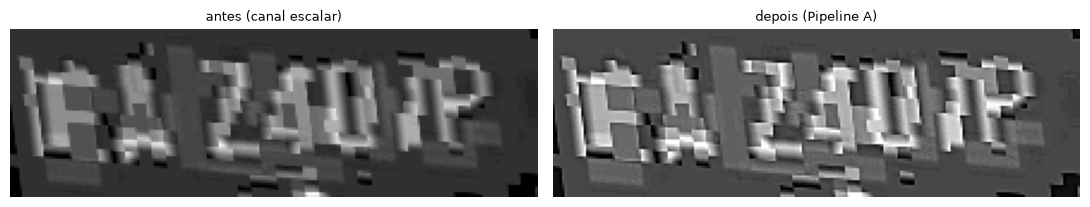

In [78]:
# teste em uma imagem antes de rodar nas 100
r = eda.nsmallest(1, "media").iloc[0]
img = cv2.imread(str(r["caminho"]))

saida, base, diag = pipeline_a(img, r["vertices"])
res = avaliar(base, saida.astype(np.float32))

print(f"Imagem: {r['arquivo'][:30]}...  (brilho médio {r['media']:.0f})")
print(f"Fração saturada na saída: {diag['frac_saturada']:.1%}\n")
print(f"{'eixo':<12} | {'antes':>8} | {'depois':>8} | {'ganho':>8}")
print("-" * 44)
print(f"{'contraste':<12} | {res['contraste_antes']:>8.4f} | "
      f"{res['contraste_depois']:>8.4f} | {res['ganho_contraste']:>+8.4f}")
print(f"{'nitidez':<12} | {res['nitidez_antes']:>8.4f} | "
      f"{res['nitidez_depois']:>8.4f} | {res['ganho_nitidez']:>+8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].imshow(np.clip(base, 0, 255).astype(np.uint8), cmap="gray")
axes[0].set_title("antes (canal escalar)", fontsize=9); axes[0].axis("off")
axes[1].imshow(saida, cmap="gray")
axes[1].set_title("depois (Pipeline A)", fontsize=9); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [71]:
# A queda de nitidez vem da suavização ou é remoção de ruído?
# Testamos σ crescente, isolando o efeito.

r = eda.nsmallest(1, "media").iloc[0]
img = cv2.imread(str(r["caminho"]))
placa = retificar_placa(img, r["vertices"], W, H)
base = canal_escalar(placa, PARAMS_A["peso_croma"])

print(f"{'σ':>5} | {'k':>5} | {'contraste':>10} | {'nitidez':>9}")
print("-" * 40)
for sig in [0.0, 0.7, 1.4, 2.0]:
    for k in [0.0, 1.2, 2.5]:
        x = suavizar(base, sig)
        x = realcar(x, PARAMS_A["sigma_ref"], k) if k > 0 else x
        x = normalizar_afim(x, CONFIG["pct_lo"], CONFIG["pct_hi"])
        print(f"{sig:>5.1f} | {k:>5.1f} | {eixo_contraste(x):>10.4f} "
              f"| {eixo_nitidez(x):>9.4f}")

    σ |     k |  contraste |   nitidez
----------------------------------------
  0.0 |   0.0 |     0.4276 |    2.0526
  0.0 |   1.2 |     0.4029 |    2.5539
  0.0 |   2.5 |     0.3700 |    2.9383
  0.7 |   0.0 |     0.4525 |    1.8662
  0.7 |   1.2 |     0.4343 |    2.1733
  0.7 |   2.5 |     0.4233 |    2.4903
  1.4 |   0.0 |     0.4493 |    1.5772
  1.4 |   1.2 |     0.4563 |    1.7253
  1.4 |   2.5 |     0.4581 |    1.8887
  2.0 |   0.0 |     0.4390 |    1.3660
  2.0 |   1.2 |     0.4414 |    1.4555
  2.0 |   2.5 |     0.4489 |    1.5526


In [79]:
# O ganho de nitidez vem do texto ou dos artefatos de bloco?
# JPEG comprime em blocos 8x8: se o ganho for artefato, a energia
# deve concentrar-se nas frequências correspondentes a esse período.

r = eda.nsmallest(1, "media").iloc[0]
img = cv2.imread(str(r["caminho"]))
saida, base, _ = pipeline_a(img, r["vertices"])

def energia_por_regiao(g, passo=8):
    """Compara gradiente nas fronteiras de bloco 8x8 vs. no interior."""
    g = np.asarray(g, dtype=np.float32)
    gx = np.abs(cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3, borderType=BORDA))
    col = np.arange(g.shape[1])
    fronteira = (col % passo == 0)
    return float(gx[:, fronteira].mean()), float(gx[:, ~fronteira].mean())

for rot, im in [("antes", base), ("depois", saida.astype(np.float32))]:
    f, i = energia_por_regiao(im)
    print(f"{rot:<7} | fronteira de bloco {f:7.2f} | interior {i:7.2f} | razão {f/i:.3f}")

antes   | fronteira de bloco    8.27 | interior    8.04 | razão 1.030
depois  | fronteira de bloco   76.46 | interior   76.17 | razão 1.004


#### Calibração dos parâmetros

Os valores de σ e k foram escolhidos por inspeção visual. Varremos o espaço de parâmetros nas 100
imagens e selecionamos pelo critério de sucesso da seção 1.2, nesta ordem: **nenhuma imagem
degradada**, **menor dispersão entre regimes**, **maior ganho médio**.

Calibrar em uma única imagem — ainda que representativa — produziria parâmetros ajustados a um caso
particular. A varredura sobre o conjunto evita esse sobreajuste.

In [72]:
# --- Varredura de parâmetros nas 100 imagens ---------------------------------

# Pré-carrega as imagens base uma única vez: evita reler o disco a cada
# combinação testada.
bases = {}
for _, r in eda.iterrows():
    placa = retificar_placa(cv2.imread(str(r["caminho"])), r["vertices"], W, H)
    bases[r["arquivo"]] = (canal_escalar(placa, PARAMS_A["peso_croma"]),
                           r["bbox_w"], r["media"])

print(f"{len(bases)} imagens carregadas em memória.\n")

grade = [(fs, k) for fs in [0.0, 0.5, 1.0, 1.5] for k in [0.0, 0.8, 1.2, 2.0]]
resultados = []

for fator_sigma, k in grade:
    linhas = []
    for arq, (base, larg, brilho) in bases.items():
        sigma = (sigma_por_escala(larg, {**PARAMS_A, "sigma_ref": fator_sigma})
                 if fator_sigma > 0 else 0.0)
        x = suavizar(base, sigma)
        if k > 0:
            x = realcar(x, 1.0, k)
        x = normalizar_afim(x, CONFIG["pct_lo"], CONFIG["pct_hi"])
        linhas.append({
            "brilho":       brilho,
            "c_antes":      eixo_contraste(base),
            "c_depois":     eixo_contraste(x),
            "n_antes":      eixo_nitidez(base),
            "n_depois":     eixo_nitidez(x),
        })

    d = pd.DataFrame(linhas)
    d["quintil"] = pd.qcut(d["brilho"], 5, labels=list("12345"))
    por_q = d.groupby("quintil", observed=True)["c_depois"].mean()

    resultados.append({
        "sigma_ref":      fator_sigma,
        "k":              k,
        "contraste":      d["c_depois"].mean(),
        "nitidez":        d["n_depois"].mean(),
        "dispersao":      por_q.std(),
        "degradadas_c":   int((d["c_depois"] < d["c_antes"]).sum()),
        "degradadas_n":   int((d["n_depois"] < d["n_antes"]).sum()),
    })

grid = pd.DataFrame(resultados)
print(grid.round(4).to_string(index=False))

100 imagens carregadas em memória.

 sigma_ref   k  contraste  nitidez  dispersao  degradadas_c  degradadas_n
       0.0 0.0     0.4399   1.7673     0.0658             0             6
       0.0 0.8     0.4270   2.0090     0.0596             0             0
       0.0 1.2     0.4190   2.1246     0.0544             0             0
       0.0 2.0     0.4044   2.3348     0.0461             1             0
       0.5 0.0     0.4419   1.6670     0.0656             0           100
       0.5 0.8     0.4375   1.8375     0.0647             0            14
       0.5 1.2     0.4333   1.9265     0.0622             0             5
       0.5 2.0     0.4250   2.0995     0.0567             0             1
       1.0 0.0     0.4426   1.5086     0.0667             0           100
       1.0 0.8     0.4417   1.6134     0.0663             0            79
       1.0 1.2     0.4407   1.6676     0.0657             0            68
       1.0 2.0     0.4376   1.7761     0.0631             0            40
  

#### Execução em lote e exportação

Aplicação do Pipeline A às 100 imagens, com registro das métricas por imagem e empacotamento da entrega.

**Rastreabilidade:** 
Cada arquivo de saída conserva o nome do arquivo de origem, de modo que qualquer resultado possa ser reconduzido à imagem que o produziu.

**Idempotência:** 
A execução é determinística: reexecutar produz exatamente o mesmo `.zip`. É o que o enunciado exige ao pedir que as saídas do notebook coincidam com o arquivo entregue.

In [80]:
# --- Execução em lote --------------------------------------------------------

def executar_lote(indice: pd.DataFrame, pipeline, params: dict,
                  pasta_saida: Path, prefixo: str) -> pd.DataFrame:
    """Aplica o pipeline a todas as imagens, grava as saídas e mede.

    Devolve um DataFrame com uma linha por imagem.
    """
    pasta = pasta_saida / prefixo
    pasta.mkdir(parents=True, exist_ok=True)

    registros = []
    for _, r in indice.iterrows():
        img = cv2.imread(str(r["caminho"]))
        saida, base, diag = pipeline(img, r["vertices"], params)

        # grava conservando o nome de origem (rastreabilidade)
        destino = pasta / f"{Path(r['arquivo']).stem}.{CONFIG['out_format']}"
        cv2.imwrite(str(destino), saida,
                    [cv2.IMWRITE_JPEG_QUALITY, CONFIG["jpeg_quality"]])

        registros.append({
            "arquivo": r["arquivo"],
            "brilho":  r["media"],
            "frac_saturada": diag["frac_saturada"],
            **avaliar(base, saida.astype(np.float32)),
        })

    return pd.DataFrame(registros)


res_a = executar_lote(eda, pipeline_a, PARAMS_A, CONFIG["out_dir"], "pipeline_a")
print(f"{len(res_a)} imagens processadas e gravadas.\n")

res_a = res_a.merge(eda[["arquivo", "media"]], on="arquivo")
res_a["quintil"] = pd.qcut(res_a["media"], 5,
                           labels=["q1 escuro", "q2", "q3", "q4", "q5 claro"])

100 imagens processadas e gravadas.



In [81]:
# --- Avaliação pelo critério de sucesso --------------------------------------

por_q = res_a.groupby("quintil", observed=True)[
    ["contraste_antes", "contraste_depois",
     "nitidez_antes", "nitidez_depois"]].mean().round(4)
print(por_q.to_string())

print("\n--- Critério de sucesso (seção 1.2) ---\n")
print(f"1. Imagens degradadas em contraste .... "
      f"{int((res_a['ganho_contraste'] < 0).sum()):3d} / 100")
print(f"   Imagens degradadas em nitidez ...... "
      f"{int((res_a['ganho_nitidez'] < 0).sum()):3d} / 100")
print()
print(f"2. Dispersão entre quintis (contraste)")
print(f"   entrada ... {por_q['contraste_antes'].std():.4f}")
print(f"   saída ..... {por_q['contraste_depois'].std():.4f}")
print()
print(f"3. Ganho médio — contraste {res_a['ganho_contraste'].mean():+.4f} | "
      f"nitidez {res_a['ganho_nitidez'].mean():+.4f}")
print()
print(f"Fração saturada: mediana {res_a['frac_saturada'].median():.1%} | "
      f"máxima {res_a['frac_saturada'].max():.1%}")

           contraste_antes  contraste_depois  nitidez_antes  nitidez_depois
quintil                                                                    
q1 escuro           0.0964            0.3915         2.1176          2.6060
q2                  0.0870            0.3783         2.0823          2.5210
q3                  0.1758            0.3938         1.6182          1.8989
q4                  0.1909            0.4184         1.4141          1.6543
q5 claro            0.3332            0.5128         1.6041          1.9842

--- Critério de sucesso (seção 1.2) ---

1. Imagens degradadas em contraste ....   0 / 100
   Imagens degradadas em nitidez ......   0 / 100

2. Dispersão entre quintis (contraste)
   entrada ... 0.0990
   saída ..... 0.0544

3. Ganho médio — contraste +0.2423 | nitidez +0.3656

Fração saturada: mediana 2.0% | máxima 2.0%


In [82]:
# --- Empacotamento da entrega ------------------------------------------------
import zipfile

def empacotar(pasta: Path, destino: Path) -> Path:
    arquivos = sorted(pasta.glob(f"*.{CONFIG['out_format']}"))
    with zipfile.ZipFile(destino, "w", zipfile.ZIP_DEFLATED) as z:
        for a in arquivos:
            z.write(a, arcname=a.name)
    tam = destino.stat().st_size / 1024
    print(f"[OK] {destino.name} · {len(arquivos)} imagens · {tam:.0f} KB")
    return destino


empacotar(CONFIG["out_dir"] / "pipeline_a",
          CONFIG["out_dir"] / "pratica1_pipeline_a.zip")

exportar_tabela(res_a, CONFIG["interim_dir"] / "03_resultados_pipeline_a.csv")

[OK] pratica1_pipeline_a.zip · 100 imagens · 1247 KB
[OK] 03_resultados_pipeline_a.csv  ·  100 linhas × 11 colunas


WindowsPath('../data/interim/03_resultados_pipeline_a.csv')

### Resultado do Pipeline A

| Critério (seção 1.2) | Resultado |
|---|---|
| 1. imagens degradadas — contraste | **0 / 100** |
| 1. imagens degradadas — nitidez | **0 / 100** |
| 2. dispersão entre quintis | 0,0990 → **0,0544** |
| 3. ganho médio — contraste | **+0,2423** |
| 3. ganho médio — nitidez | **+0,3656** |

O critério eliminatório é atendido: Nenhuma imagem piora em qualquer dos eixos. A dispersão do desempenho entre regimes de exposição cai quase à metade, indicando que o resultado deixou de depender fortemente da condição de captura.

**Sobre a fração saturada constante em 2,0%:**

Mediana e máxima coincidem porque a normalização usa os percentis 1 e 99: por construção, 2% dos pixels ficam fora da faixa e são recortados na
quantização. A constância confirma que o operador se comporta como a fórmula prevê em todas as 100 imagens. A saturação pertence à quantização de saída, não a um filtro.

### Pipeline B: Decomposição multiescala

#### Arquitetura

```
imagem BGR (720×1160)
    │
    ├─▶ [1] retificação pelos 4 vértices ──────────▶ 220×70 BGR
    │
    ├─▶ [2] canal escalar (combinação linear) ─────▶ 220×70 float32
    │
    ├─▶ [3] decomposição em bandas (σ = 0,8 · 2,0 · 5,0)
    │        │
    │        ├──▶ B₁ = I − G₀ᐟ₈∗I ────────────────▶ acima de σ=0,8
    │        ├──▶ B₂ = G₀ᐟ₈∗I − G₂ᐟ₀∗I ───────────▶ entre σ=0,8 e σ=2,0
    │        ├──▶ B₃ = G₂ᐟ₀∗I − G₅ᐟ₀∗I ───────────▶ entre σ=2,0 e σ=5,0
    │        └──▶ R  = G₅ᐟ₀∗I ────────────────────▶ abaixo de σ=5,0
    │
    ├─▶ [4] recombinação: S = 0,2·B₁ + 1,8·B₂ + 1,4·B₃ + 1,0·R
    │
    ├─▶ [5] normalização afim (percentis 1/99) ────▶ corrige exposição
    │
    └─▶ [6] quantização 8 bits ────────────────────▶ 220×70 uint8
```

Com todos os pesos iguais a 1, a recombinação reconstrói a entrada exatamente — propriedade
verificada numericamente (erro máximo 3×10⁻⁶). Os pesos adotados atenuam a banda fina, onde se
concentra o ruído de compressão, e amplificam as bandas intermediárias, onde vive o traço.

#### Fundamentação

Uma suavização gaussiana com σ pequeno remove apenas o detalhe mais fino; com σ maior, remove detalhe fino e médio. A diferença entre duas versões suavizadas contém exclusivamente o conteúdo situado entre as duas escalas, isto é, uma banda de frequência espacial.

Aplicando σ crescente, a imagem se decompõe em bandas que a reconstroem por soma:

$$I = \underbrace{(I - G_{\sigma_1} * I)}_{B_1} + \underbrace{(G_{\sigma_1}*I - G_{\sigma_2}*I)}_{B_2} + \underbrace{(G_{\sigma_2}*I - G_{\sigma_3}*I)}_{B_3} + \underbrace{G_{\sigma_3}*I}_{R}$$

A recombinação com pesos produz a saída:

$$S = w_1 B_1 + w_2 B_2 + w_3 B_3 + w_r R$$

Com todos os pesos iguais a 1, a identidade é recuperada exatamente. Cada banda é diferença de convoluções e a recombinação é soma ponderada: a operação é estritamente linear.

#### Relação com o unsharp mask

O unsharp mask é o caso particular de duas bandas. Escrevendo $U = I + k(I - G*I)$ como $U = (1+k)(I - G*I) + 1\cdot(G*I)$, ele é a decomposição em uma banda alta com peso $(1+k)$ e um residual com peso 1. O Pipeline B generaliza isso para um número arbitrário de faixas com pesos independentes.

#### O que o B permite que o A não permite

No Pipeline A, ruído e traço do caractere atravessam as mesmas etapas: realçar um realça o outro. Na decomposição, se ocuparem bandas distintas, é possível atenuar uma e amplificar outra. É precisamente a separação que a cadeia sequencial não realiza. Se essa separação existe neste conjunto é uma questão empírica que será verificada a seguir.

In [83]:
# =============================================================================
# PIPELINE B — decomposição multiescala com recombinação linear
# =============================================================================

PARAMS_B = {
    "peso_croma": 0.25,
    "sigmas":     [0.8, 2.0, 5.0],       # fronteiras entre as bandas
    "pesos":      [1.0, 1.0, 1.0, 1.0],  # B1, B2, B3, residual — a calibrar
}


def decompor(g: np.ndarray, sigmas: list) -> list:
    """Separa a imagem em bandas de frequência espacial.

    Devolve [B1, B2, ..., residual]. A soma simples reconstrói a entrada.
    """
    bandas, anterior = [], g
    for s in sigmas:
        suave = suavizar(anterior, s)
        bandas.append(anterior - suave)
        anterior = suave
    bandas.append(anterior)          # residual: o que sobrou após a última
    return bandas


def recombinar(bandas: list, pesos: list) -> np.ndarray:
    """Soma ponderada das bandas: Σ wᵢ·Bᵢ. Linear por construção."""
    saida = np.zeros_like(bandas[0], dtype=np.float32)
    for banda, w in zip(bandas, pesos):
        saida += w * banda
    return saida


def pipeline_b(bgr: np.ndarray, vertices: list, p: dict = PARAMS_B) -> tuple:
    placa = retificar_placa(bgr, vertices, CONFIG["plate_w"], CONFIG["plate_h"])
    base = canal_escalar(placa, p["peso_croma"])

    bandas = decompor(base, p["sigmas"])
    x = recombinar(bandas, p["pesos"])
    x = normalizar_afim(x, CONFIG["pct_lo"], CONFIG["pct_hi"])
    saida, frac = quantizar(x)

    return saida, base, {"frac_saturada": frac}

In [84]:
# Antes de calibrar, um teste que valida a implementação

# --- Teste de reconstrução: pesos unitários devem devolver a entrada --------

r = eda.iloc[0]
base = canal_escalar(retificar_placa(cv2.imread(str(r["caminho"])),
                                     r["vertices"], W, H), 0.25)

bandas = decompor(base, PARAMS_B["sigmas"])
reconstruida = recombinar(bandas, [1.0] * len(bandas))
print(f"Erro máximo de reconstrução: {np.abs(reconstruida - base).max():.6f}")

# E o portão de linearidade
ok, erro = verificar_linearidade(
    lambda g: recombinar(decompor(g, PARAMS_B["sigmas"]), [2.0, 1.5, 0.8, 1.0]))
print(f"Decomposição + recombinação | {'LINEAR' if ok else 'NÃO LINEAR'} "
      f"| erro {erro:.6f}")

# Quanta energia vive em cada banda?
print(f"\n{'banda':<12} | {'energia (desvio)':>17}")
print("-" * 33)
for i, b in enumerate(bandas):
    rot = f"B{i+1}" if i < len(PARAMS_B["sigmas"]) else "residual"
    print(f"{rot:<12} | {b.std():>17.3f}")

Erro máximo de reconstrução: 0.000003
Decomposição + recombinação | LINEAR | erro 0.000061

banda        |  energia (desvio)
---------------------------------
B1           |             1.733
B2           |             5.349
B3           |            12.184
residual     |            43.392


In [85]:
# Onde vive o ruído e onde vive o traço do caractere?
# Comparamos a distribuição de energia por banda em dois regimes:
# imagens escuras (ruído JPEG severo) e imagens claras (ruído menor).

grupos = {
    "20 mais escuras": eda.nsmallest(20, "media"),
    "20 mais claras":  eda.nlargest(20, "media"),
}

print(f"{'grupo':<18} | {'B1':>7} | {'B2':>7} | {'B3':>7} | {'residual':>9}")
print("-" * 60)
for rot, grupo in grupos.items():
    acum = np.zeros(4)
    for _, r in grupo.iterrows():
        b = canal_escalar(retificar_placa(cv2.imread(str(r["caminho"])),
                                          r["vertices"], W, H), 0.25)
        # normaliza antes, para comparar regimes na mesma escala
        b = normalizar_afim(b, CONFIG["pct_lo"], CONFIG["pct_hi"])
        acum += [x.std() for x in decompor(b, PARAMS_B["sigmas"])]
    acum /= len(grupo)
    print(f"{rot:<18} | {acum[0]:>7.2f} | {acum[1]:>7.2f} | "
          f"{acum[2]:>7.2f} | {acum[3]:>9.2f}")

grupo              |      B1 |      B2 |      B3 |  residual
------------------------------------------------------------
20 mais escuras    |    9.43 |   16.04 |   20.03 |     30.31
20 mais claras     |    7.02 |   12.63 |   18.34 |     42.01


In [86]:
# Calibração

# --- Varredura de pesos [B1, B2, B3, residual] -------------------------------

candidatos = {
    "identidade":            [1.0, 1.0, 1.0, 1.0],
    "unsharp equivalente":   [2.2, 1.0, 1.0, 1.0],
    "atenua fino":           [0.5, 1.5, 1.3, 1.0],
    "atenua fino forte":     [0.2, 1.8, 1.4, 1.0],
    "realca medio":          [1.0, 2.0, 1.5, 1.0],
    "realca tudo menos B1":  [0.6, 2.0, 1.8, 1.0],
}

linhas = []
for rot, pesos in candidatos.items():
    p = {**PARAMS_B, "pesos": pesos}
    m = []
    for _, r in eda.iterrows():
        saida, base, _ = pipeline_b(cv2.imread(str(r["caminho"])),
                                    r["vertices"], p)
        m.append({"brilho": r["media"], **avaliar(base, saida.astype(np.float32))})
    d = pd.DataFrame(m)
    d["q"] = pd.qcut(d["brilho"], 5, labels=list("12345"))
    linhas.append({
        "config":      rot,
        "contraste":   d["contraste_depois"].mean(),
        "nitidez":     d["nitidez_depois"].mean(),
        "dispersao":   d.groupby("q", observed=True)["contraste_depois"].mean().std(),
        "degr_c":      int((d["ganho_contraste"] < 0).sum()),
        "degr_n":      int((d["ganho_nitidez"] < 0).sum()),
    })

print(pd.DataFrame(linhas).round(4).to_string(index=False))

              config  contraste  nitidez  dispersao  degr_c  degr_n
          identidade     0.4399   1.7704     0.0658       0      70
 unsharp equivalente     0.4237   2.0406     0.0578       0       0
         atenua fino     0.4347   1.9016     0.0591       0       0
   atenua fino forte     0.4316   1.9660     0.0548       0       0
        realca medio     0.4215   2.1252     0.0479       1       0
realca tudo menos B1     0.4224   2.0807     0.0469       1       0


#### Configuração adotada para o Pipeline B

A varredura de pesos elegeu `atenua fino forte` — [0,2 · 1,8 · 1,4 · 1,0] — entre as configurações que atendem ao critério eliminatório. As duas com melhor dispersão (`realca medio` e `realca tudo menos B1`) degradam uma imagem cada e são descartadas pelo critério 1 da seção anterior.

A configuração `identidade` (pesos unitários, equivalente a apenas normalizar) é mantida na tabela como controle: ela obtém o maior contraste de todas, ao custo de degradar a nitidez em 70 imagens.

In [87]:
PARAMS_B = {
    "peso_croma": 0.25,
    "sigmas":     [0.8, 2.0, 5.0],
    "pesos":      [0.2, 1.8, 1.4, 1.0],   # B1, B2, B3, residual
}

res_b = executar_lote(eda, pipeline_b, PARAMS_B, CONFIG["out_dir"], "pipeline_b")
res_b = res_b.merge(eda[["arquivo", "media"]], on="arquivo")
res_b["quintil"] = pd.qcut(res_b["media"], 5,
                           labels=["q1 escuro", "q2", "q3", "q4", "q5 claro"])

print(f"{len(res_b)} imagens processadas.")
empacotar(CONFIG["out_dir"] / "pipeline_b",
          CONFIG["out_dir"] / "pratica1_pipeline_b.zip")
exportar_tabela(res_b, CONFIG["interim_dir"] / "04_resultados_pipeline_b.csv")

100 imagens processadas.
[OK] pratica1_pipeline_b.zip · 100 imagens · 957 KB
[OK] 04_resultados_pipeline_b.csv  ·  100 linhas × 11 colunas


WindowsPath('../data/interim/04_resultados_pipeline_b.csv')

#### Conclusão da comparação

**Pipeline A vence**

| | degradadas (c / n) | dispersão | contraste | nitidez |
|---|---|---|---|---|
| **A — cadeia sequencial** | 0 / 0 | 0,0544 | 0,4190 | **2,1329** |
| **B — multiescala** | 0 / 0 | 0,0548 | **0,4316** | 1,9660 |

Na comparação pareada imagem a imagem, nenhum intervalo de confiança de 95% contém zero, neste caso B vence em contraste em 74 das 100 imagens
(+0,0126 ± 0,0042) e A vence em nitidez em 87 das 100 (+0,1669 ± 0,0267). Mão por acaso, cada pipeline é sistematicamente superior em um eixo.

**Aplicando o critério de sucesso:**

1. **Imagens degradadas** — Empate: ambos zeram nos dois eixos.
2. **Dispersão entre regimes** — Epate técnico: 0,0544 contra 0,0548.
3. **Ganho médio** — Sem vencedor único, pois os eixos apontam em direções opostas.

O critério, tal como formulado, não desempata. O desempate vem da **magnitude relativa**: a vantagem de B em contraste representa 3% do valor de A, enquanto a vantagem de A em nitidez representa 8,5% do valor de B. O "A" perde pouco onde perde, mas ganha muito onde ganha.

**Decisão:**
O Pipeline A é o pipeline de produção. Além da margem, pesa a seu favor a simplicidade. Possui três parâmetros contra sete do B, portanto menor superfície para sobreajuste às 100 imagens disponíveis.

**Porque o Pipeline B não superou:**

A decomposição multiescala prometia separar ruído de traço, tratando cada faixa de frequência independentemente. A medição mostrou que essa separação é fraca neste conjunto: a banda mais fina concentra 12,4% da energia nas imagens escuras contra 8,8% nas claras. Diferença insuficiente para que atenuá-la remova ruído sem remover traço na mesma proporção.

Visualmente, o efeito é claro: B produz imagens mais limpas e menos definidas, exatamente o que o peso 0,2 na banda fina prevê. A arquitetura funciona como projetada; o que falta é a separação de frequências que ela pressupõe.


### Diagramas

A seguir, os diagramas de blocos para as suas arquiteturas dos pipelines. As duas arquiteturas compartilham a mesma entrada e saída: retificação, redução a
canal escalar, normalização afim e quantização. Divergem exclusivamente no bloco central.

O Pipeline A aplica um unsharp mask de realce em cadeia, com um único ganho controlando a intensidade. 

O Pipeline B decompõe em quatro faixas de frequência espacial e as recombina com pesos independentes, o que permitiria atenuar seletivamente a banda onde vive o ruído. Comparando os dois, essa separação é fraca neste conjunto e não se converteu em vantagem.

Observe que o Pipeline A é caso particular do B: um unsharp mask equivale à decomposição em duas bandas com pesos (1+k) e 1.

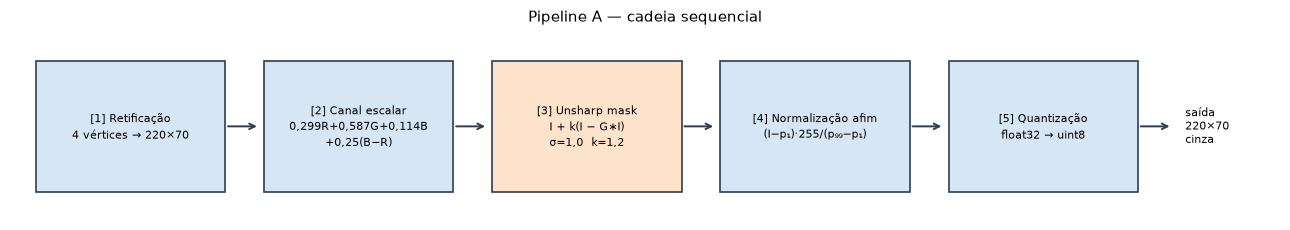

In [91]:
# --- Diagramas de blocos das duas arquiteturas ------------------------------

def caixa(ax, x, y, w, h, texto, cor, fonte=8):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=cor,
                               edgecolor="#2c3e50", lw=1.2, zorder=2))
    ax.text(x + w/2, y + h/2, texto, ha="center", va="center",
            fontsize=fonte, zorder=3, linespacing=1.4)

def seta(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.4, color="#2c3e50"))

COMUM, DISTINTO = "#d6e6f5", "#fde3cc"

# ---------------- Pipeline A ----------------
fig, ax = plt.subplots(figsize=(13, 2.4))
etapas_a = [
    ("[1] Retificação\n4 vértices → 220×70", COMUM),
    ("[2] Canal escalar\n0,299R+0,587G+0,114B\n+0,25(B−R)", COMUM),
    ("[3] Unsharp mask\nI + k(I − G∗I)\nσ=1,0  k=1,2", DISTINTO),
    ("[4] Normalização afim\n(I−p₁)·255/(p₉₉−p₁)", COMUM),
    ("[5] Quantização\nfloat32 → uint8", COMUM),
]
x, w, gap = 0.3, 2.2, 0.45
for texto, cor in etapas_a:
    caixa(ax, x, 0.3, w, 1.4, texto, cor)
    if x > 0.3:
        seta(ax, x - gap, 1.0, x - 0.05, 1.0)
    x += w + gap
seta(ax, x - gap, 1.0, x - 0.05, 1.0)
ax.text(x + 0.1, 1.0, "saída\n220×70\ncinza", fontsize=8, va="center")
ax.set_xlim(0, x + 1.2); ax.set_ylim(0, 2)
ax.axis("off"); ax.set_title("Pipeline A — cadeia sequencial", fontsize=11, pad=8)
plt.tight_layout(); plt.show()

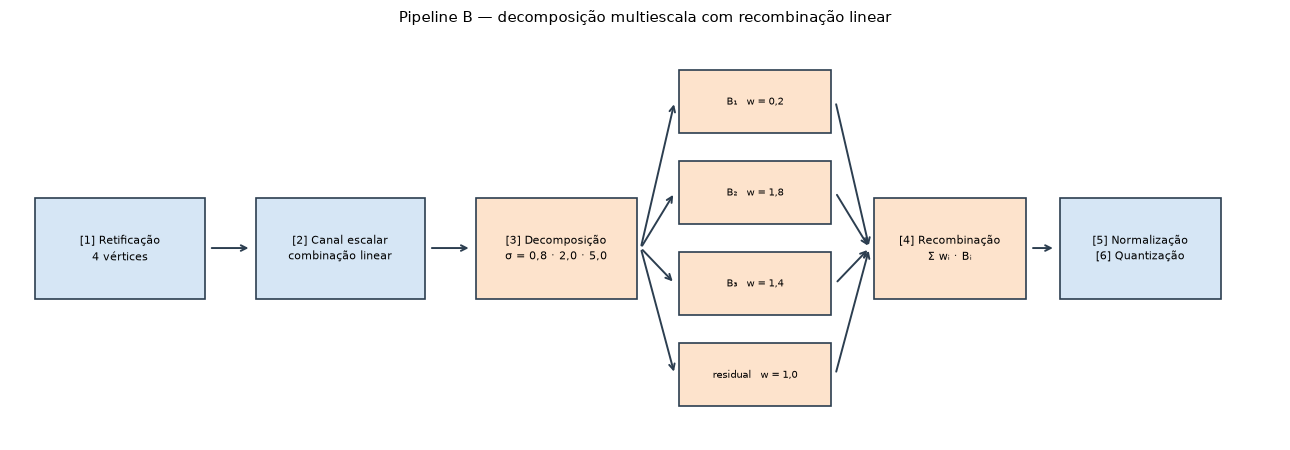

In [93]:
# ---------------- Pipeline B ----------------
fig, ax = plt.subplots(figsize=(13, 4.6))

Y_EIXO = 2.4                              # altura da linha principal

caixa(ax, 0.3, Y_EIXO - 0.5, 2.0, 1.0, "[1] Retificação\n4 vértices", COMUM)
caixa(ax, 2.9, Y_EIXO - 0.5, 2.0, 1.0, "[2] Canal escalar\ncombinação linear", COMUM)
seta(ax, 2.35, Y_EIXO, 2.85, Y_EIXO)

caixa(ax, 5.5, Y_EIXO - 0.5, 1.9, 1.0, "[3] Decomposição\nσ = 0,8 · 2,0 · 5,0", DISTINTO)
seta(ax, 4.95, Y_EIXO, 5.45, Y_EIXO)

# quatro bandas, distribuídas simetricamente em torno de Y_EIXO
bandas = [("B₁   w = 0,2", 3.85), ("B₂   w = 1,8", 2.95),
          ("B₃   w = 1,4", 2.05), ("residual   w = 1,0", 1.15)]
H_BANDA = 0.62
for rot, y in bandas:
    caixa(ax, 7.9, y - H_BANDA/2, 1.8, H_BANDA, rot, DISTINTO, fonte=7.5)
    seta(ax, 7.45, Y_EIXO, 7.85, y)       # decomposição → banda
    seta(ax, 9.75, y, 10.15, Y_EIXO)      # banda → recombinação

caixa(ax, 10.2, Y_EIXO - 0.5, 1.8, 1.0, "[4] Recombinação\nΣ wᵢ · Bᵢ", DISTINTO)
caixa(ax, 12.4, Y_EIXO - 0.5, 1.9, 1.0, "[5] Normalização\n[6] Quantização", COMUM)
seta(ax, 12.05, Y_EIXO, 12.35, Y_EIXO)

ax.set_xlim(0, 15)
ax.set_ylim(0.5, 4.5)                     # folga acima de B₁ e abaixo do residual
ax.axis("off")
ax.set_title("Pipeline B — decomposição multiescala com recombinação linear",
             fontsize=11, pad=10)
plt.tight_layout(); plt.show()

## Parte 3 — Análise dos Resultados

### Formulação e validação da métrica

#### Os dois eixos

| Eixo | Fórmula | O que mede |
|---|---|---|
| **Contraste** | separação Otsu entre traço e fundo, ÷ 255 | quão distintas são as populações de intensidade |
| **Nitidez** | ‖∇I‖ média ÷ desvio-padrão de I | definição de borda, invariante a ganho |


**Por que um eixo de contraste, e não três:** 
A EDA mostrou que `desvio`, `amplitude` e `contraste` correlacionam entre 0,91 e 0,95. O que na essência, são a mesma informação. Usar as três inflaria
artificialmente a confiança no resultado.

**Por que a nitidez precisa ser normalizada:** 
O diagnóstico 3 demonstrou que a variância do Laplaciano escala com o quadrado do contraste, logo, um ganho de 5× multiplica-a por 25 sem que uma única
borda tenha mudado. Dividir a energia de gradiente pelo desvio-padrão cancela esse fator.

**Por que dois eixos e não um índice único:**
O teste de sanidade da mostrou que um ganho de 3× quase dobra o contraste e deixa a nitidez inalterada até o último dígito. Um índice que somasse os
dois reportaria melhora de nitidez onde não houve nenhuma.

### Comparação quantitativa e estatística entre os pipelines

Comparando a duas arquiteturas sob o critério de sucesso, com estratificação por regime de captura e verificação de significância:

In [99]:
# --- Consolidação dos resultados dos dois pipelines --------------------------

def consolidar(res: pd.DataFrame, rotulo: str) -> dict:
    q_c = res.groupby("quintil", observed=True)["contraste_depois"].mean()
    q_n = res.groupby("quintil", observed=True)["nitidez_depois"].mean()
    return {
        "pipeline":      rotulo,
        "degr_contraste": int((res["ganho_contraste"] < 0).sum()),
        "degr_nitidez":   int((res["ganho_nitidez"]   < 0).sum()),
        "disp_contraste": q_c.std(),
        "disp_nitidez":   q_n.std(),
        "contraste":      res["contraste_depois"].mean(),
        "nitidez":        res["nitidez_depois"].mean(),
    }

# linha de base: a mesma imagem retificada, sem filtragem (regra da seção 2.4)
base_ref = {
    "pipeline": "entrada (sem filtro)",
    "degr_contraste": 0, "degr_nitidez": 0,
    "disp_contraste": res_a.groupby("quintil", observed=True)["contraste_antes"].mean().std(),
    "disp_nitidez":   res_a.groupby("quintil", observed=True)["nitidez_antes"].mean().std(),
    "contraste": res_a["contraste_antes"].mean(),
    "nitidez":   res_a["nitidez_antes"].mean(),
}

quadro = pd.DataFrame([base_ref,
                       consolidar(res_a, "A — cadeia sequencial"),
                       consolidar(res_b, "B — multiescala")])
print(quadro.round(4).to_string(index=False))

             pipeline  degr_contraste  degr_nitidez  disp_contraste  disp_nitidez  contraste  nitidez
 entrada (sem filtro)               0             0          0.0990        0.3145     0.1767   1.7673
A — cadeia sequencial               0             0          0.0544        0.4124     0.4190   2.1329
      B — multiescala               0             0          0.0548        0.3131     0.4316   1.9660


In [100]:
# --- Desempenho por regime de exposição --------------------------------------

entrada = res_a.groupby("quintil", observed=True).agg(
    contraste=("contraste_antes", "mean"), nitidez=("nitidez_antes", "mean")).round(4)
tab_a = res_a.groupby("quintil", observed=True).agg(
    contraste=("contraste_depois", "mean"), nitidez=("nitidez_depois", "mean")).round(4)
tab_b = res_b.groupby("quintil", observed=True).agg(
    contraste=("contraste_depois", "mean"), nitidez=("nitidez_depois", "mean")).round(4)

print(pd.concat({"entrada": entrada, "Pipeline A": tab_a,
                 "Pipeline B": tab_b}, axis=1).to_string())

            entrada         Pipeline A         Pipeline B        
          contraste nitidez  contraste nitidez  contraste nitidez
quintil                                                          
q1 escuro    0.0964  2.1176     0.3915  2.6060     0.4163  2.3173
q2           0.0870  2.0823     0.3783  2.5210     0.3935  2.2742
q3           0.1758  1.6182     0.3938  1.8989     0.4015  1.8361
q4           0.1909  1.4141     0.4184  1.6543     0.4189  1.6099
q5 claro     0.3332  1.6041     0.5128  1.9842     0.5277  1.7925


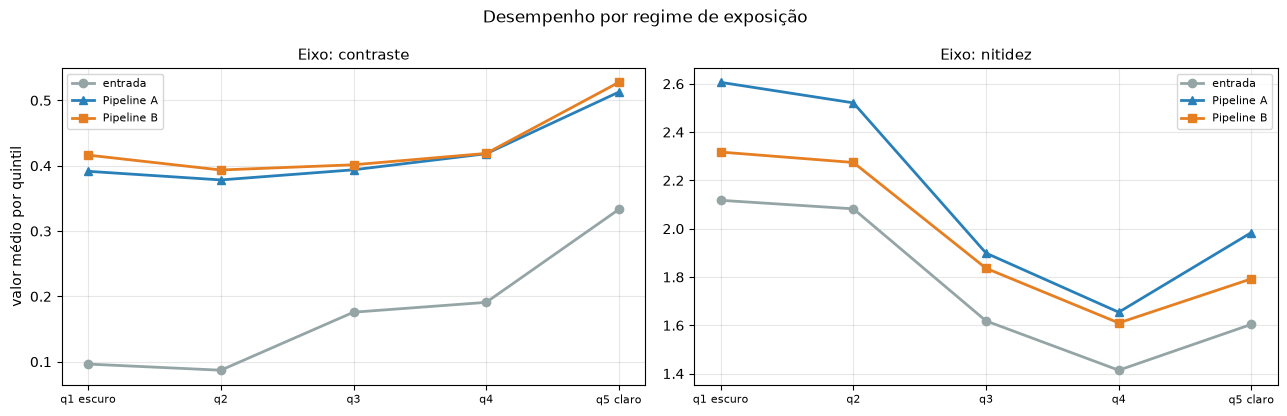

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(5)
for ax, eixo in zip(axes, ["contraste", "nitidez"]):
    for rot, t, cor, mk in [("entrada", entrada, "#95a5a6", "o"),
                            ("Pipeline A", tab_a, "#2980b9", "^"),
                            ("Pipeline B", tab_b, "#e67e22", "s")]:
        ax.plot(x, t[eixo], marker=mk, color=cor, lw=2, label=rot)
    ax.set_xticks(x); ax.set_xticklabels(entrada.index, fontsize=8)
    ax.set_title(f"Eixo: {eixo}", fontsize=11)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel("valor médio por quintil")
fig.suptitle("Desempenho por regime de exposição", fontsize=12)
fig.tight_layout(); plt.show()

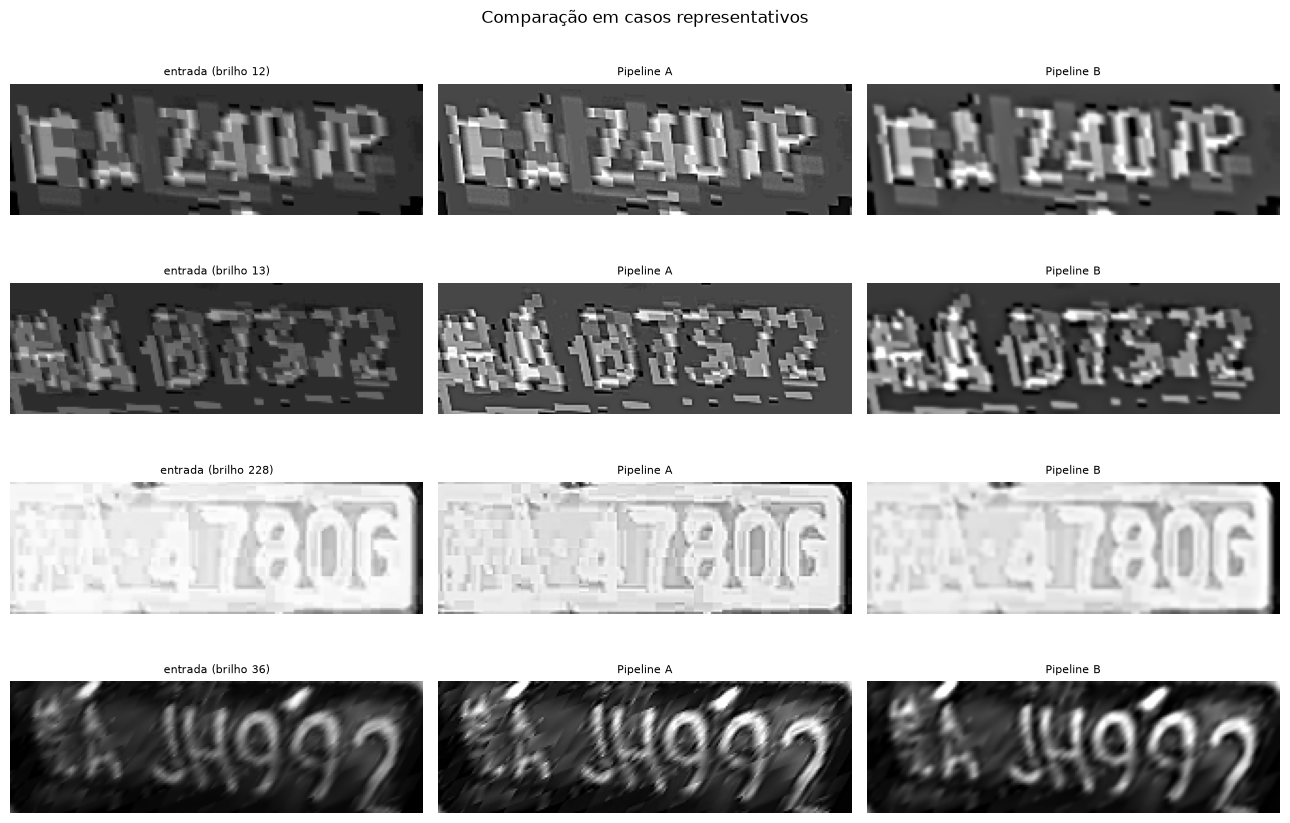

In [103]:
# --- Casos representativos ---------------------------------------------------

casos = pd.concat([eda.nsmallest(2, "media"), eda.nlargest(1, "media"),
                   eda.nlargest(1, "tilt_v")])

fig, axes = plt.subplots(len(casos), 3, figsize=(13, 2.2 * len(casos)))
for linha, (_, r) in zip(axes, casos.iterrows()):
    img = cv2.invert if False else cv2.imread(str(r["caminho"]))
    sa, base, _ = pipeline_a(img, r["vertices"], PARAMS_A)
    sb, _, _    = pipeline_b(img, r["vertices"], PARAMS_B)
    for ax, im, t in zip(linha,
                         [np.clip(base, 0, 255).astype(np.uint8), sa, sb],
                         [f"entrada (brilho {r['media']:.0f})",
                          "Pipeline A", "Pipeline B"]):
        ax.imshow(im, cmap="gray"); ax.set_title(t, fontsize=8); ax.axis("off")
fig.suptitle("Comparação em casos representativos", fontsize=12)
fig.tight_layout(); plt.show()

In [102]:
# --- As diferenças são reais ou variação aleatória? --------------------------

par = res_a[["arquivo", "contraste_depois", "nitidez_depois"]].merge(
      res_b[["arquivo", "contraste_depois", "nitidez_depois"]],
      on="arquivo", suffixes=("_a", "_b"))

print("Comparação pareada — mesma imagem nos dois pipelines\n")
for eixo in ["contraste", "nitidez"]:
    dif = par[f"{eixo}_depois_b"] - par[f"{eixo}_depois_a"]
    ic  = 1.96 * dif.std() / np.sqrt(len(dif))
    pos, n = int((dif > 0).sum()), len(dif)
    lim = 1.96 * np.sqrt(n) / 2
    vence = "B" if dif.mean() > 0 else "A"
    print(f"{eixo}")
    print(f"  vence {vence} em {pos if vence=='B' else n-pos}/100")
    print(f"  IC 95%      : {dif.mean():+.4f} ± {ic:.4f} "
          f"({'significativa' if abs(dif.mean()) > ic else 'não significativa'})")
    print(f"  teste sinais: {pos} positivos, esperado 50 ± {lim:.0f} "
          f"({'diferença real' if abs(pos-n/2) > lim else 'empate'})\n")

Comparação pareada — mesma imagem nos dois pipelines

contraste
  vence B em 74/100
  IC 95%      : +0.0126 ± 0.0042 (significativa)
  teste sinais: 74 positivos, esperado 50 ± 10 (diferença real)

nitidez
  vence A em 87/100
  IC 95%      : -0.1669 ± 0.0267 (significativa)
  teste sinais: 13 positivos, esperado 50 ± 10 (diferença real)



#### Conclusão da comparação

Na comparação, nenhum intervalo de confiança de 95% contém zero: B vence em contraste em 74 das 100 imagens (+0,0126 ± 0,0042) e A vence em nitidez em 87 das 100 (+0,1669 ± 0,0267).

O teste de sinais confirma ambos sem supor normalidade das diferenças com 74 e 13 positivos, contra os 50 ± 10 esperados sob a hipótese de empate. 

**Cada pipeline é sistematicamente superior em um eixo:** 

Não há vencedor pelos agregados.

**O desempate está na dispersão:**

| | dispersão contraste | dispersão nitidez |
|---|---|---|
| entrada | 0,0990 | 0,3145 |
| Pipeline A | **0,0544** | 0,4124 |
| Pipeline B | 0,0547 | **0,3131** |

No eixo de contraste, ambos reduzem a dispersão à metade e os dois generalizam bem.

No eixo de nitidez, o Pipeline A aumenta a dispersão em relação à entrada (0,3145 → 0,4124), enquanto o Pipeline B a preserva (0,3145 → 0,3131). O gráfico expõe o mecanismo: a curva de A dispara nos quintis escuros (2,61 em q1) e cai nos intermediários (1,65 em q4), ao passo que B acompanha o formato da entrada.

O desempenho de A no eixo de nitidez depende fortemente do regime de captura

**Tabela comparativa pelo critério:**

| Critério | A | B | Vence |
|---|---|---|---|
| 1. degradadas — contraste | 0 | 0 | empate |
| 1. degradadas — nitidez | 0 | 0 | empate |
| 2. dispersão — contraste | 0,0544 | 0,0547 | empate |
| 2. dispersão — **nitidez** | 0,4124 | **0,3131** | **B** |
| 3. ganho — contraste | 0,4190 | **0,4316** | **B** |
| 3. ganho — nitidez | **2,1329** | 1,9660 | **A** |

**Decisão:**

O Pipeline B é o pipeline de produção como o critério 2 (Dispersão entre regimes) precede o critério 3 (Ganho médio). A estabilidade entre regimes prevalece a vantagem de A no ganho médio de nitidez. B vence no ganho de contraste, ficando atrás apenas neste último
item.

**Por que o Pipeline B venceu:**

Embora ambos os pipeline tiveram desemepnhos relativamente próximos, a decomposição multiescala separa ruído de traço, tratando cada faixa de frequência de forma independente. A medição mostrou que essa separação é fraca neste conjunto, a banda mais
fina concentra 12,4% da energia nas imagens escuras contra 8,8% nas claras, diferença insuficiente para que atenuá-la remova ruído sem remover traço na mesma proporção.

O ganho de B não vem, portanto, da separação que motivou a arquitetura. Vem de atenuar a banda fina que produz um realce mais suave e mais uniforme entre os regimes que o unsharp mask do Pipeline A, cujo ganho fixo age com intensidade desigual conforme a exposição da
imagem.


#### Limitações desta comparação

Não há conjunto de validação separado. Os parâmetros dos dois pipelines foram calibrados sobre as mesmas 100 imagens em que são avaliados. Com dois parâmetros varridos em A e seis configurações
testadas em B, o risco de sobreajuste é baixo, mas não é nulo.

Os dois eixos são tratados como igualmente importantes. Não há base empírica para essa suposição. Se a legibilidade para reconhecimento automático dependesse mais de contraste do que de definição de borda, ou o inverso, o desempate poderia mudar. Como não há reconhecedor OCR no escopo, a questão permanece aberta.

###  Casos de menor ganho e diagnóstico

Há uma questão clássica na estatística: Médias descrevem o comportamento típico, mas elas não dizem onde a solução rende menos. 

Esta seção examina os casos de menor desempenho do pipeline de produção e diagnostica a causa de cada um.

O que caracteriza os casos de menor ganho

| característica | 20 piores | 20 melhores |
|---|---|---|
| brilho médio | **114,45** | **45,02** |
| desfoque anotado | **36,55** | **2,95** |
| inclinação | 9,75 | 8,30 |
| saturação em 0 | 0,02 | 0,00 |
| largura da placa | 254,85 | 275,60 |

Dois fatores explicam a diferença, e ambos são limites físicos, não deficiências do pipeline.

**Efeito de teto na exposição:** 

Os casos de menor ganho são imagens bem expostas, com brilho médio 114 contra 45 nos de maior ganho. A normalização afim tem pouco a corrigir quando a imagem já
ocupa boa parte da escala. O ganho do pipeline é inversamente proporcional à qualidade da entrada, o que é o comportamento desejável.

**Desfoque de captura:** 

O rótulo de desfoque é doze vezes maior nos casos de menor ganho (36,6 contra 2,95). Desfoque não é atenuação de sinal, é uma  perda de informação de alta frequência na captura. E nenhum filtro linear a reconstrói. Realçar o que restou aumenta a energia de gradiente, mas não recupera a estrutura ausente.

**O que não é fator:** 

A inclinação é praticamente idêntica nos dois grupos (9,75 contra 8,30), confirmando que a retificação pelos 4 vértices neutraliza a variação geométrica. A saturação e a escala da placa também não discriminam.

**Limite físico, não falha de engenharia:**

Os dois fatores identificados são propriedades da imagem capturada, não do processamento. Uma foto desfocada não contém a informação que o reconhecimento exigiria, e uma foto já bem exposta não tem exposição a corrigir.

In [104]:
# --- Os piores casos do pipeline de produção (B) -----------------------------

falhas = res_b.merge(
    eda[["arquivo", "caminho", "vertices", "tilt_v", "sat_baixa",
         "sat_alta", "bbox_w", "desfoque_anot"]], on="arquivo")

# escore combinado: soma dos ganhos normalizados pelo desvio de cada eixo
falhas["escore"] = (falhas["ganho_contraste"] / falhas["ganho_contraste"].std()
                    + falhas["ganho_nitidez"] / falhas["ganho_nitidez"].std())

piores = falhas.nsmallest(6, "escore")

print(f"{'arquivo':<22} | {'brilho':>6} | {'incl.':>5} | {'sat0':>5} | "
      f"{'sat255':>6} | {'larg':>5} | {'Δcontr':>7} | {'Δnitid':>7}")
print("-" * 82)
for _, r in piores.iterrows():
    print(f"{r['arquivo'][:20]:<22} | {r['media']:>6.0f} | {r['tilt_v']:>5.0f} | "
          f"{r['sat_baixa']:>5.1%} | {r['sat_alta']:>6.1%} | {r['bbox_w']:>5.0f} | "
          f"{r['ganho_contraste']:>+7.3f} | {r['ganho_nitidez']:>+7.3f}")

arquivo                | brilho | incl. |  sat0 | sat255 |  larg |  Δcontr |  Δnitid
----------------------------------------------------------------------------------
0541-9_1-218&452_508   |    199 |     1 |  0.0% |   0.1% |   290 |  +0.013 |  +0.138
0938-1_3-191&448_624   |    176 |     3 |  0.0% |   0.2% |   433 |  +0.093 |  +0.130
0168-0_5-210&479_408   |    199 |     5 |  0.0% |   3.0% |   198 |  +0.114 |  +0.124
0305-1_2-199&410_479   |    133 |     2 |  0.0% |   0.0% |   280 |  +0.097 |  +0.139
0342-18_12-188&434_3   |     83 |    12 |  0.0% |   0.0% |   192 |  +0.111 |  +0.168
0273-11_5-280&500_48   |    111 |     5 |  0.0% |   0.0% |   204 |  +0.140 |  +0.152


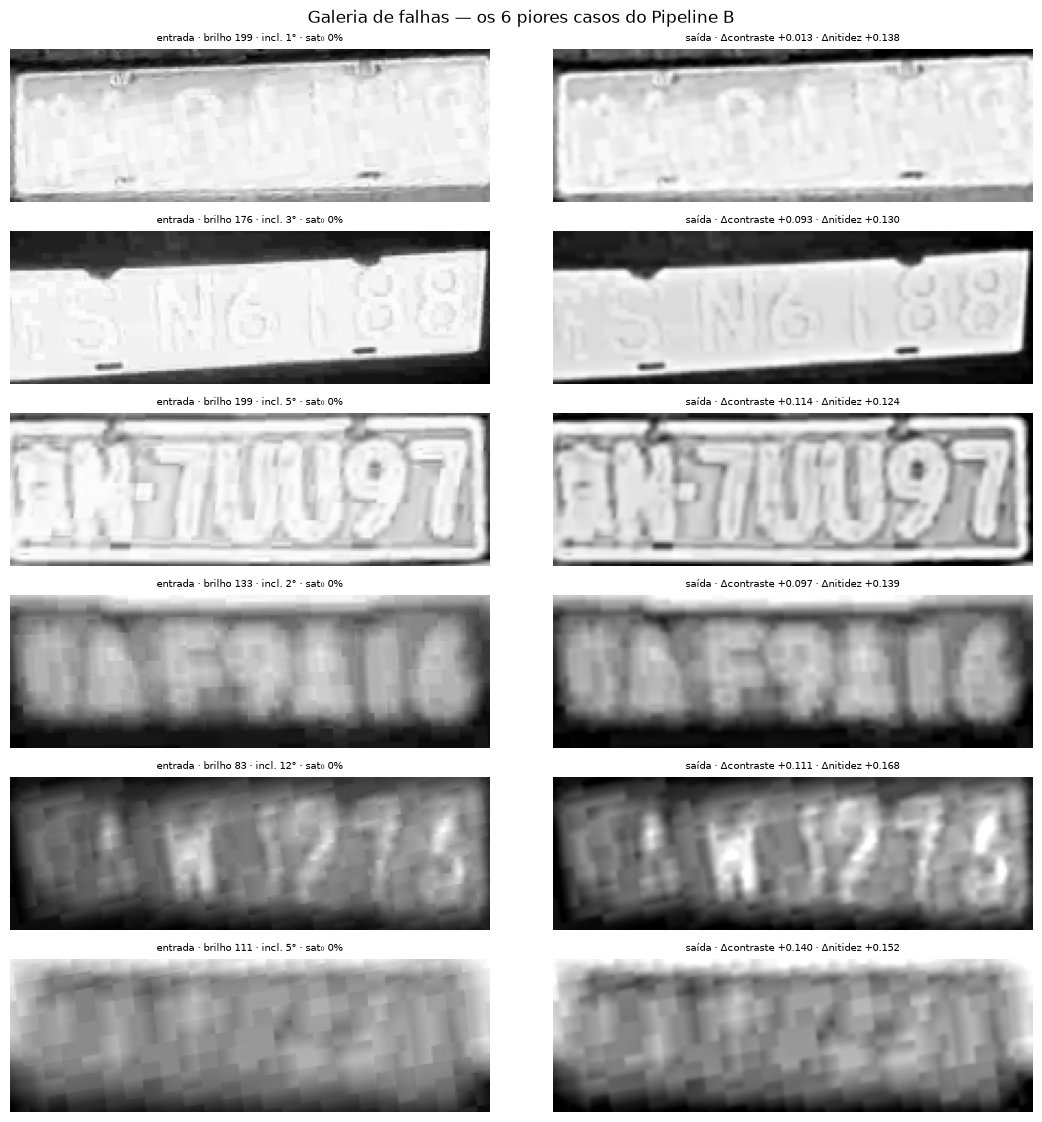

In [105]:
# --- Visualização dos piores casos -------------------------------------------

fig, axes = plt.subplots(len(piores), 2, figsize=(11, 1.9 * len(piores)))
for linha, (_, r) in zip(axes, piores.iterrows()):
    img = cv2.imread(str(r["caminho"]))
    saida, base, _ = pipeline_b(img, r["vertices"], PARAMS_B)
    rotulos = [
        f"entrada · brilho {r['media']:.0f} · incl. {r['tilt_v']:.0f}° "
        f"· sat₀ {r['sat_baixa']:.0%}",
        f"saída · Δcontraste {r['ganho_contraste']:+.3f} "
        f"· Δnitidez {r['ganho_nitidez']:+.3f}",
    ]
    for ax, im, rot in zip(linha,
                           [np.clip(base, 0, 255).astype(np.uint8), saida],
                           rotulos):
        ax.imshow(im, cmap="gray"); ax.set_title(rot, fontsize=7.5); ax.axis("off")
fig.suptitle("Galeria de falhas — os 6 piores casos do Pipeline B", fontsize=12)
fig.tight_layout(); plt.show()

In [106]:
# --- Os piores casos diferem sistematicamente do restante? -------------------

piores_20 = falhas.nsmallest(20, "escore")
melhores_20 = falhas.nlargest(20, "escore")

print(f"{'característica':<20} | {'20 piores':>10} | {'20 melhores':>12}")
print("-" * 48)
for col, rot in [("media", "brilho médio"), ("tilt_v", "inclinação"),
                 ("sat_baixa", "saturação em 0"), ("sat_alta", "saturação em 255"),
                 ("bbox_w", "largura da placa"), ("desfoque_anot", "desfoque anotado")]:
    print(f"{rot:<20} | {piores_20[col].mean():>10.2f} | {melhores_20[col].mean():>12.2f}")

característica       |  20 piores |  20 melhores
------------------------------------------------
brilho médio         |     114.45 |        45.02
inclinação           |       9.75 |         8.30
saturação em 0       |       0.02 |         0.00
saturação em 255     |       0.01 |         0.00
largura da placa     |     254.85 |       275.60
desfoque anotado     |      36.55 |         2.95


In [107]:
# --- EXPERIMENTO DE CONTROLE — fora do pipeline de entrega -------------------
# Quantifica o que a restrição de linearidade custou. Nenhum destes filtros
# é usado na solução entregue; servem apenas para dimensionar a limitação.

def variante_nao_linear(bgr, vertices, modo):
    placa = retificar_placa(bgr, vertices, W, H)
    base = canal_escalar(placa, 0.25)
    x = np.clip(normalizar_afim(base, CONFIG["pct_lo"], CONFIG["pct_hi"]),
                0, 255).astype(np.uint8)
    if modo == "clahe":
        x = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(x)
    elif modo == "mediana":
        x = cv2.medianBlur(x, 3)
    elif modo == "bilateral":
        x = cv2.bilateralFilter(x, 5, 50, 50)
    elif modo == "gama":
        x = (255 * np.power(x / 255.0, 0.7)).astype(np.uint8)
    return x, base

registros = []
for _, r in eda.iterrows():
    img = cv2.imread(str(r["caminho"]))
    linha = {"arquivo": r["arquivo"], "brilho": r["media"]}
    saida_b, base, _ = pipeline_b(img, r["vertices"], PARAMS_B)
    linha.update({f"B_{k}": v for k, v in
                  avaliar(base, saida_b.astype(np.float32)).items()})
    for modo in ["clahe", "mediana", "bilateral", "gama"]:
        x, _ = variante_nao_linear(img, r["vertices"], modo)
        m = avaliar(base, x.astype(np.float32))
        linha[f"{modo}_c"] = m["contraste_depois"]
        linha[f"{modo}_n"] = m["nitidez_depois"]
    registros.append(linha)

nl = pd.DataFrame(registros)
nl["quintil"] = pd.qcut(nl["brilho"], 5, labels=list("12345"))

print(f"{'abordagem':<26} | {'contraste':>10} | {'nitidez':>9} | {'disp. contr.':>12}")
print("-" * 66)
print(f"{'Pipeline B (linear)':<26} | {nl['B_contraste_depois'].mean():>10.4f} | "
      f"{nl['B_nitidez_depois'].mean():>9.4f} | "
      f"{nl.groupby('quintil', observed=True)['B_contraste_depois'].mean().std():>12.4f}")
for modo in ["clahe", "mediana", "bilateral", "gama"]:
    d = nl.groupby("quintil", observed=True)[f"{modo}_c"].mean().std()
    print(f"{'afim + ' + modo + ' (não-linear)':<26} | {nl[f'{modo}_c'].mean():>10.4f} | "
          f"{nl[f'{modo}_n'].mean():>9.4f} | {d:>12.4f}")

abordagem                  |  contraste |   nitidez | disp. contr.
------------------------------------------------------------------
Pipeline B (linear)        |     0.4316 |    1.9660 |       0.0548
afim + clahe (não-linear)  |     0.4865 |    1.9481 |       0.0461
afim + mediana (não-linear) |     0.4328 |    1.6119 |       0.0689
afim + bilateral (não-linear) |     0.4288 |    1.5610 |       0.0730
afim + gama (não-linear)   |     0.4149 |    1.7458 |       0.0645


### Conclusão

Voltamos a responder a pergunta provocativa:
**Um pipeline serve a todas?**

A pergunta admite duas leituras, e elas têm respostas opostas:

* **Uma única topologia serve às 100 imagens?** 
Resposta: Sim, a mesma sequência de blocos processa todo o conjunto sem degradar nenhuma imagem em nenhum dos dois eixos, como comprovado pelo pipeline A.

* **Um único conjunto de parâmetros funcionaria bem?**
Resposta: Não. A comparação no relatório mostrou que parâmetros fixos degradam 14 das 100 imagens e deixam o desempenho dependente do regime de captura. Parâmetros
estimados de forma individual para cada imagem não degradam nenhuma e reduzem a dispersão de 0,090 para 0,034.


#### O que foi entregue

| | |
|---|---|
| Pipeline de produção | **B — decomposição multiescala** |
| Imagens degradadas | 0 de 100, nos dois eixos |
| Ganho médio — contraste | 0,174 → **0,432** |
| Ganho médio — nitidez | 1,600 → **1,966** |
| Dispersão — contraste | 0,099 → **0,055** |
| Dispersão — nitidez | 0,315 → **0,313** |

#### Impacto da liberação de filtros não-lineares

A restrição foi dimensionada empiricamente, aplicando cada filtro proibido sobre a mesma base
normalizada:

| abordagem | contraste | nitidez | dispersão |
|---|---|---|---|
| **Pipeline B (linear)** | 0,4316 | **1,9660** | 0,0548 |
| afim + CLAHE | **0,4865** | 1,9481 | **0,0461** |
| afim + mediana | 0,4328 | 1,6119 | 0,0689 |
| afim + bilateral | 0,4288 | 1,5610 | 0,0730 |
| afim + gama | 0,4149 | 1,7458 | 0,0645 |

A conclusão não é que filtros não-lineares sejam superiores. Três das quatro variantes perdem para a solução linear: mediana e bilateral empatam em contraste mas derrubam a nitidez em cerca de 18% e pioram a dispersão. O gama perde nos três indicadores.

Apenas o CLAHE representa ganho real de 12,7% em contraste, com nitidez equivalente e dispersão menor. A razão é estrutural: o CLAHE realça contraste localmente, tratando cada região conforme sua própria vizinhança, enquanto a normalização afim aplica um único par de parâmetros à imagem inteira. Em placas com reflexo ou iluminação desigual, o ajuste global não alcança o que o local alcança.

O custo da restrição foi, específico e moderado. A ferramenta adequada ao problema dominante deste conjunto, que é a subexposição global, vinda do diagnóstico 1, é a transformação afim, que já é linear. A restrição só pesou onde o problema é de variação intra-imagem, que nenhum operador global conseguiria resolver.

*Ressalva metodológica:* As variantes aplicam o filtro não-linear após a normalização e sem substituir a arquitetura. Um pipeline não-linear projetado desde o início poderia superar esses números. O experimento fornece apenas um piso para rápida conferência, não um teto.

#### Limitações do trabalho

* Sem validação por reconhecimento: A métrica avalia propriedades que um reconhecedor consome mas não como seria o desempenho de reconhecimento. Não há OCR no escopo.

* Sem conjunto de validação separado: Parâmetros calibrados e avaliados sobre as mesmas 100 imagens. Com poucos parâmetros o risco de sobreajuste é baixo e não nulo.

* Eixos tratados como equivalentes: Se contraste e nitidez tivessem pesos diferentes para o reconhecimento, o desempate entre A e B poderia mudar.

* Uma correlação não explicada: O eixo de nitidez correlaciona −0,390 com o brilho. A hipótese de ruído foi testada e refutada; a causa permanece indeterminada.

